# DSAI Mini Coursework
**Student Name**: Sa
**Student Email**: tnpdung.79@gmail.com  
**Student Discord Username**: xiaosha5668  
**Submission Date**: 12 Jul 2026

---

## How this coursework is assessed

You are a data scientist hired by a lending business. Read `business_brief.md` and `data_dictionary.md` in this folder **before writing any code**.

**There is no single right answer.** You are assessed on how well you think and explain your decisions, not just on your final score.

| Section | Marks | What is assessed |
|---|---|---|
| 1 — Understanding the Problem | 10 | Can you frame the business problem correctly before touching any data? |
| 2 — Setup & Data Loading | 3 | Clean data loading and basic sanity checks |
| 3 — Exploring the Data | 10 | Quality of your exploratory analysis and commentary |
| 4 — Cleaning & Joining | 12 | Correct joins, deduplication, missing-value handling, transaction aggregation |
| 5 — Feature Engineering | 15 | WoE/IV implementation and domain-driven ratio features |
| 6 — Training Models | 15 | Model implementation, tuning, and justification of choices |
| 7 — Evaluating Your Model | 8 | Diagnostic plots and interpretation |
| 8 — Business Impact | 12 | Expected Loss calculation and business recommendation |
| 9 — Drift Detection | 5 | Understanding of production monitoring |
| Extension | **10** | Optional distinction-level tasks |
| **Total** | **100** | |

> **Every code cell must be followed by a text cell explaining what you did and why.** Code without explanation will not receive full marks.

---
# SECTION 1 — Understanding the Problem *(10 marks)*

Before writing any code, show that you understand what the business actually needs.  
Read `business_brief.md` and `data_dictionary.md`, then answer the questions below in your own words.

**1.1** *(1 mark)* In your own words, what problem is FinVista trying to solve, and why does it cost them money?

*Your answer: 

FinVista is facing a credit risk problem because its current rule-based credit scorecard, built five years ago, can no longer accurately identify low-risk and high-risk loan applicants. As a result, more high-risk borrowers are being approved, causing the default rate to increase from 7% to over 10% in the past 18 months.

This has become costly because approving high-risk borrowers increases the portfolio's Expected Loss. When these borrowers default, FinVista loses money through Loss Given Default (LGD), leading to approximately £4.2 million in unexpected credit losses. However, the company cannot simply approve fewer loans because it must maintain an approval rate of at least 70% to remain competitive and avoid losing market share. Therefore, FinVista aims to improve its credit approval decisions by approving more creditworthy applicants while rejecting those with a high risk of default.

To solve this problem, FinVista plans to replace its existing rule-based scorecard with a machine learning-based credit scoring model. The model will predict the Probability of Default (PD) for each loan application, helping the company make better approve/reject decisions, reduce Expected Loss, and maintain the required approval rate.

---

**1.2** *(2 marks)* What kind of ML task is this — classification or regression? What column are you trying to predict? What does one row in your training data represent?

*Your answer:*

This is a binary classification problem because the objective is to predict whether a loan applicant will default or not. Although the model produces a Probability of Default (PD) as its output, the target variable is binary (default_flag), indicating whether a borrower eventually defaults. Therefore, the task is to classify loan applications into default and non-default categories while estimating the likelihood of default.

The target column is default_flag from the loans.csv dataset. This variable serves as the ground truth for model training, where a value of 1 indicates that the loan defaulted and 0 indicates that it was successfully repaid.

Each row in the training dataset represents one loan application, not one customer. A customer may apply for multiple loans, but each application is treated as an independent observation. Therefore, the model learns to predict the default outcome for each individual loan application based on the applicant's demographic information, credit history, aggregated transaction behaviour, and loan-related features.

---

**1.3** *(3 marks)* The bank measures model quality using a number called the **Gini score** (closely related to AUC). Why is Gini a better measure than simple accuracy (% of correct predictions) when only about 10% of customers default?

*Hint: imagine a model that predicts "will not default" for every single customer — what accuracy does it get? Is it a useful model?*

What would a Gini of **0** mean? What would a Gini of **1** mean?

*Your answer:*

Gini is more useful than accuracy because the dataset is imbalanced. Only about 10% of customers default, while around 90% do not. A model that predicts "will not default" for every customer would achieve about 90% accuracy, but it would fail to identify any defaulting customers. Therefore, high accuracy does not necessarily mean the model performs well. 

Gini measures how well the model distinguishes between defaulting and non-defaulting customers. A higher Gini score means the model is better at ranking high-risk customers above low-risk customers, making it a more suitable metric for credit scoring. 

A Gini score of 0 means the model has no predictive power. It performs no better than random guessing and cannot distinguish between defaulting and non-defaulting customers. 

A Gini score of 1 means the model has perfect discrimination. It correctly ranks every defaulting customer above every non-defaulting customer.

---

**1.4** *(2 marks)* The bank must approve at least 70% of all applicants. Think about the two types of mistake a model can make:

- **Mistake A**: the model rejects a customer who would actually have repaid the loan.
- **Mistake B**: the model approves a customer who then defaults and the bank loses money.

Which mistake is more costly to the bank? Which is more costly to the customer? Given the 70% approval requirement, which mistake should you be more careful about?

*Your answer:*

Mistake B is more costly to the bank because approving a customer who later defaults results in financial losses and increases the portfolio's Expected Loss.

Mistake A is more costly to the customer because a creditworthy applicant is denied a loan that they could have repaid successfully.

Given the 70% approval requirement, the model should be more careful about Mistake B. Since the bank must approve at least 70% of applicants, it cannot simply reject more customers to reduce risk. Instead, the model should accurately identify high-risk borrowers so that the bank can reduce Expected Loss while still meeting the required approval rate.

---

**1.5** *(2 marks)* The `transactions` table has many rows per customer (one row per purchase). The `loans` table has one row per loan. Why can you not join them together directly? What do you need to do first?

*Your answer:*

The transactions table cannot be joined directly with the loans table because they have different levels of granularity. The transactions table contains one row per transaction, while the loans table contains one row per loan application. A direct join would create multiple rows for each loan application, leading to duplicated records and incorrect model training.

Before joining the tables, the transactions data must be aggregated to one row per customer_id. For example, we can calculate features such as the total transaction amount, number of transactions, average transaction amount, cash advance count, or spending by category. The aggregated transaction features can then be joined with the loan-level data using customer_id.


In [2]:
# Import libraries — add any others you need
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Reproducibility and display settings
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
SNAPSHOT = pd.Timestamp('2026-06-20')

sns.set_theme(style="whitegrid", palette="deep") # Use consistent chart styling.

print("Setup complete.")


Setup complete.


### Setup commentary: 
Imported the libraries needed for data manipulation and visualisation and set `RANDOM_STATE = 42` so that later train-validation splits and model results are reproducible. `SNAPSHOT` is set to 20 June 2026, as specified in the business brief, and will be used later for recency-based transaction features.

In [3]:
# Data lives in the data/ folder alongside this notebook.
# To generate it: run `python ../generate_dataset.py` from the repo root.

# --- ADD YOUR CODE BELOW ---
# Locate the supplied data folder.
DATA_DIR = Path("data")

customers = pd.read_csv(
    DATA_DIR / "customers.csv",
    parse_dates=["date_of_birth"]
)

credit_history = pd.read_csv(DATA_DIR / "credit_history.csv")

transactions = pd.read_csv(
    DATA_DIR / "transactions.csv",
    parse_dates=["txn_date"]
)

loans = pd.read_csv(
    DATA_DIR / "loans.csv",
    parse_dates=["application_date"]
)

# Store tables in one dictionary for compact checks in later sections.
datasets = {
    "customers": customers,
    "credit_history": credit_history,
    "transactions": transactions,
    "loans": loans
}

summary = pd.DataFrame({
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
}, index=datasets.keys())

summary

,Rows,Columns
customers,8000,12
credit_history,8000,11
transactions,479860,7
loans,10040,9


### Data-loading commentary:
All four source tables loaded successfully. `customers` and `credit_history` should each contain 8,000 rows because they are customer-level tables. `loans` contains 10,040 loan applications, including suspected duplicate applications that will be investigated in the data-quality section. `transactions` contains 479,860 records and is much larger because it is recorded at transaction grain rather than customer or loan-application grain.

The date columns were parsed during loading so that they can later be used for age, recency, cohort, and point-in-time feature calculations.

*Note the row count of each table. Does anything look wrong or unexpected?*

---
# SECTION 3 — Exploring the Data (EDA) *(15 marks)*

Before building any model, you need to understand the data — what it contains, what problems it has, and which columns might be useful for prediction.

Work through the four sub-sections below. After each block of charts, write a short commentary explaining what you found and what you will do about it.

### 3.1 Data Quality Check *(4 marks)*

Before doing anything else, check the health of the data.

In [4]:
# --- ADD YOUR CODE BELOW ---
# Things to check:
# - For each table: what is the data type of each column? How many values are missing?
# - Are there any duplicate rows? (hint: check loans for duplicate loan applications)
# - Do all customer IDs in the loans and transactions tables exist in the customers table?
# - How many loans are defaults (default_flag = 1) vs non-defaults? What percentage default?

from IPython.display import Markdown, display

# ------------------------------------------------------------
# 1. Data type and missing value analysis
# ------------------------------------------------------------

def dataset_summary(df):
    return pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str).values,
        "Missing": df.isna().sum().values
    })

datasets = {
    "Customers": customers,
    "Credit History": credit_history,
    "Transactions": transactions,
    "Loans": loans
}

for name, df in datasets.items():
    display(Markdown(f"## {name}"))
    display(Markdown(f"**Rows:** {df.shape[0]:,} &nbsp;&nbsp; **Columns:** {df.shape[1]}"))
    display(dataset_summary(df))


## Customers

**Rows:** 8,000 &nbsp;&nbsp; **Columns:** 12

,Column,Data Type,Missing
0,customer_id,str,0
1,date_of_birth,datetime64[us],0
2,age,int64,0
3,education,str,0
4,employment_status,str,0
5,annual_income,float64,334
6,housing_status,str,0
7,months_at_address,float64,422
8,marital_status,str,0
9,n_dependents,int64,0


## Credit History

**Rows:** 8,000 &nbsp;&nbsp; **Columns:** 11

...

**Rows:** 479,860 &nbsp;&nbsp; **Columns:** 7

,Column,Data Type,Missing
0,txn_id,str,0
1,customer_id,str,0
2,txn_date,datetime64[us],0
3,txn_amount,float64,0
4,txn_category,str,0
5,channel,str,0
6,cash_stress_flag,int64,0


## Loans

**Rows:** 10,040 &nbsp;&nbsp; **Columns:** 9

,Column,Data Type,Missing
0,loan_id,str,0
1,customer_id,str,0
2,application_date,datetime64[us],0
3,loan_amount,int64,0
4,loan_purpose,str,192
5,term_months,int64,0
6,interest_rate,float64,0
7,default_flag,int64,0
8,loss_given_default,float64,0


In [5]:
# ------------------------------------------------------------
# 2. Data duplication analysis
# ------------------------------------------------------------

# Summarize the number of duplicate rows in each dataset
duplicate_summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Duplicate Rows": [df.duplicated().sum() for df in datasets.values()]
})

display(duplicate_summary)
# Loan duplication check: we consider a loan application to be a duplicate if the same customer applied for the same loan amount on the same date.
duplicate_loans = loans.duplicated(
    subset=["customer_id", "application_date", "loan_amount"]
).sum()

print(f"Duplicate loan applications: {duplicate_loans}")

,Dataset,Duplicate Rows
0,Customers,0
1,Credit History,0
2,Transactions,0
3,Loans,0


Duplicate loan applications: 41


In [6]:
# ------------------------------------------------------------
# 3. Customer ID consistency check
# ------------------------------------------------------------

#Customer ID consistency check: ensure that all customer IDs in the loans and transactions tables exist in the customers table.
loan_missing_ids = ~loans["customer_id"].isin(customers["customer_id"])
txn_missing_ids = ~transactions["customer_id"].isin(customers["customer_id"])

id_check = pd.DataFrame({
    "Table": ["Loans", "Transactions"],
    "Missing Customer IDs": [
        loan_missing_ids.sum(),
        txn_missing_ids.sum()
    ]
})

display(id_check)
# error customer IDs in loans and transactions that do not exist in customers (if any
loans.loc[loan_missing_ids, "customer_id"].unique()
transactions.loc[txn_missing_ids, "customer_id"].unique()

,Table,Missing Customer IDs
0,Loans,0
1,Transactions,0


<StringArray>
[]
Length: 0, dtype: str

In [7]:
# ------------------------------------------------------------
# 4. Defaults and Non-defaults analysis
# ------------------------------------------------------------
target_summary = (
    loans["default_flag"]
    .value_counts()
    .rename(index={0: "Non-default", 1: "Default"})
    .to_frame("Count")
)

target_summary["Percentage"] = (
    target_summary["Count"] / len(loans) * 100
).round(2)

display(target_summary)

,Count,Percentage
default_flag,,
Non-default,9032,89.96
Default,1008,10.04


**What did you find?** List each problem, whether it is a genuine error or informative (e.g. a missing value that actually means something), and what you will do about it.

*Your answer:*
 
### Data types:
The data types are generally appropriate for each variable. Date fields have been correctly parsed as datetime, numerical variables are stored as integer or floating-point types, and categorical variables remain as string (object) values. Several variables are stored as float64 because they contain missing values rather than true decimal values.
### Missing values:
Several variables contain missing values, including annual_income, months_at_address, credit_score, n_inquiries_12m, months_since_deliq, and loan_purpose. However, not all missing values represent data quality issues. According to the data dictionary, some missing values are expected and carry business meaning. For example, a missing value in months_since_deliq indicates that the customer has never been delinquent, while missing loan_purpose reflects an optional application field. These variables will be handled using different strategies during data preprocessing rather than applying a single imputation method.
### Duplication:
No duplicate rows are expected in 4 tables. However, the loans table may contain 41 duplicate loan applications. These will be removed before model development to avoid duplicated observations affecting model training.
### Customer ID:
All customer IDs in the loans and transactions tables should exist in the customers table because customer_id is the foreign key linking the four datasets. There are no missing in this coursework. 
### Default vs Non-default classification: 
The variable is imbalanced, with approximately 10% of loan applications resulting in default and around 90% being non-default. This means that accuracy alone would be misleading, as a model predicting every applicant as non-default would still achieve high accuracy. Therefore, the model will be evaluated using Gini and AUC, which better measure its ability to distinguish between defaulting and non-defaulting borrowers.

### 3.2 Distribution of Each Column *(3 marks)*

Look at each column individually to understand what values it takes.


Customers


,count,mean,std,min,25%,50%,75%,max
age,8000.0,37.66,11.44,18.0,29.0,37.0,45.0,75.0
annual_income,7666.0,68348.24,82023.79,8000.0,37200.0,58500.0,86400.0,2833197.0
months_at_address,7578.0,36.29,35.19,1.0,11.0,25.0,50.0,300.0
n_dependents,8000.0,1.21,1.21,0.0,0.0,1.0,2.0,4.0
months_as_customer,8000.0,48.64,46.50,1.0,14.0,35.0,68.0,240.0



Credit History


,count,mean,std,min,25%,50%,75%,max
credit_score,7748.0,622.97,58.03,417.0,585.0,623.00,662.00,850.0
n_open_accounts,8000.0,8.56,5.23,0.0,4.0,9.00,13.00,17.0
total_credit_limit,8000.0,108040.98,63722.11,3700.0,51400.0,98200.00,172025.00,200000.0
credit_utilization,8000.0,0.43,0.19,0.0,0.3,0.43,0.57,1.0
months_oldest_account,8000.0,65.18,59.07,6.0,23.0,47.00,88.00,360.0
n_delinquencies_24m,8000.0,0.26,0.53,0.0,0.0,0.00,0.00,4.0
n_public_records,8000.0,0.14,0.41,0.0,0.0,0.00,0.00,2.0
n_inquiries_12m,7610.0,1.20,1.11,0.0,0.0,1.00,2.00,7.0
months_since_deliq,1778.0,12.86,6.92,1.0,7.0,13.00,19.00,24.0
mortgage_balance,8000.0,65258.38,119635.92,0.0,0.0,0.00,101250.00,800000.0



Transactions


,count,mean,std,min,25%,50%,75%,max
txn_amount,479860.0,746.15,993.44,1.0,156.06,413.37,941.79,25000.0
cash_stress_flag,479860.0,0.04,0.20,0.0,0.00,0.00,0.00,1.0



Loans


,count,mean,std,min,25%,50%,75%,max
loan_amount,10040.0,13762.85,11337.47,2000.00,5000.00,10000.00,20000.00,50000.00
term_months,10040.0,38.54,14.00,12.00,24.00,36.00,48.00,60.00
interest_rate,10040.0,0.17,0.04,0.04,0.13,0.17,0.21,0.25
default_flag,10040.0,0.10,0.30,0.00,0.00,0.00,0.00,1.00
loss_given_default,10040.0,1187.14,4609.37,0.00,0.00,0.00,0.00,47435.60


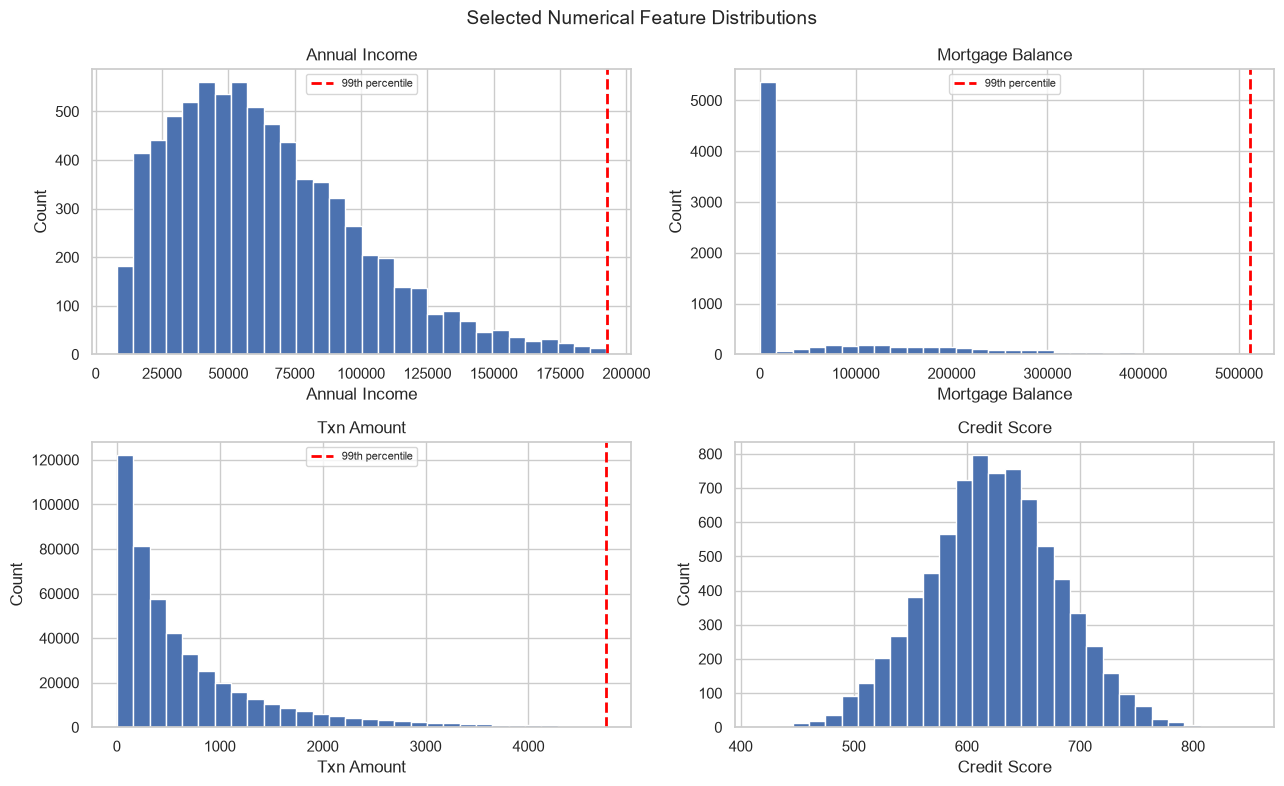

In [8]:
# --- ADD YOUR CODE BELOW ---
# For each numeric column: plot a histogram. Does the distribution look normal, skewed, or unusual?
# For each text/category column: plot a bar chart showing how many rows fall in each category.
# Note any columns with extreme outliers or very unusual distributions.


## Numeric Columns
numeric_cols = {
    "Customers": customers.select_dtypes(include=np.number),
    "Credit History": credit_history.select_dtypes(include=np.number),
    "Transactions": transactions.select_dtypes(include=np.number),
    "Loans": loans.select_dtypes(include=np.number)
}

for name, df in datasets.items():
    print(f"\n{name}")
    display(
        df.select_dtypes(include=np.number)
          .describe()
          .T
          .round(2)
    )
### Numercal Distributions
hist_features = [
    ("Customers", customers, "annual_income", True),
    ("Credit History", credit_history, "mortgage_balance", True),
    ("Transactions", transactions, "txn_amount", True),
    ("Credit History", credit_history, "credit_score", False)
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, (table, df, col, clip_99) in zip(axes, hist_features):

    original = df[col].dropna()

    if clip_99:
        p99 = original.quantile(0.99)
        data = original[original <= p99]

        ax.hist(data, bins=30)
        ax.axvline(
            p99,
            color="red",
            linestyle="--",
            linewidth=2,
            label="99th percentile"
        )
        ax.legend(fontsize=8)

    else:
        ax.hist(original, bins=30)

    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel("Count")

plt.suptitle("Selected Numerical Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()





Customers


,count,unique,top,freq
customer_id,8000,8000,C000001,1
education,8000,5,bachelors,2489
employment_status,8000,5,employed_full,4385
housing_status,8000,5,mortgaged,2643
marital_status,8000,4,married,3626
region,8000,5,Southeast,1990



Credit History


,count,unique,top,freq
customer_id,8000,8000,C000001,1



Transactions


,count,unique,top,freq
txn_id,479860,479860,T00000001,1
customer_id,479860,8000,C003017,92
txn_category,479860,10,grocery,81604
channel,479860,4,in_store,192120



Loans


,count,unique,top,freq
loan_id,10040,10040,L0000001,1
customer_id,10040,5699,C000225,8
loan_purpose,9848,8,debt_consolidation,2735


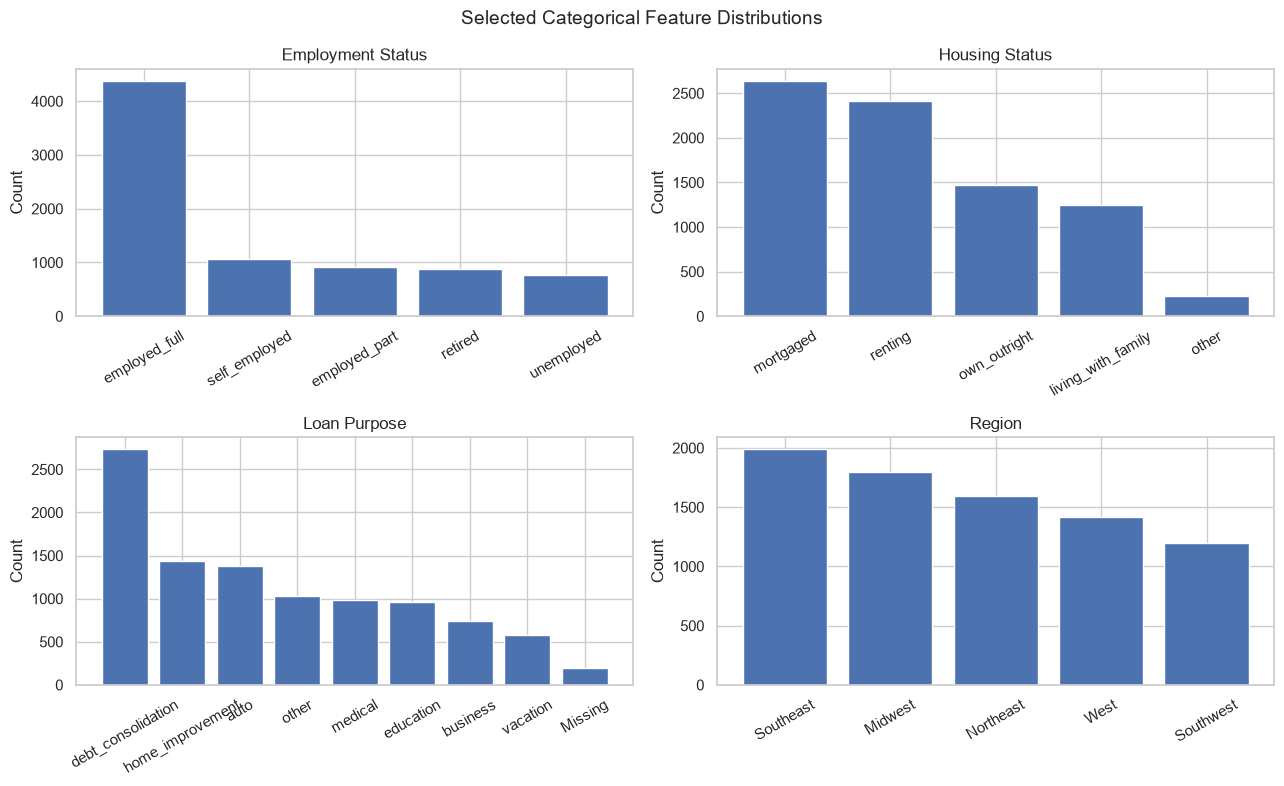

In [9]:
##Caregorical Columns
categorical_cols = {
    "Customers": customers.select_dtypes(include="object"),
    "Credit History": credit_history.select_dtypes(include="object"),
    "Transactions": transactions.select_dtypes(include="object"),
    "Loans": loans.select_dtypes(include="object")
}

for name, df in datasets.items():
    print(f"\n{name}")
    display(
        df.select_dtypes(include="object")
          .describe()
          .T
    )

## Categorical Distributions

bar_features = [
    ("Customers", customers, "employment_status"),
    ("Customers", customers, "housing_status"),
    ("Loans", loans, "loan_purpose"),
    ("Customers", customers, "region")
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, (table, df, col) in zip(axes, bar_features):

    counts = (
        df[col]
        .fillna("Missing")
        .value_counts()
    )

    ax.bar(counts.index.astype(str), counts.values)

    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Selected Categorical Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

**What did you notice?** Name any columns with extreme outliers or very skewed distributions, and say how you plan to handle them.

*Your answer:*
# Numerical feature distributions 
The summary statistics and selected histograms show that most numerical variables fall within reasonable ranges, but several features exhibit highly right-skewed distributions with extreme outliers. In particular, annual_income, mortgage_balance, and txn_amount have maximum values that are substantially higher than their upper quartiles, indicating the presence of a small number of unusually large observations. Following the recommendation in the data dictionary, the histograms are displayed up to the 99th percentile to better visualise the majority of the data while preserving the original values. During data preprocessing, these variables will be assessed for 99th percentile capping (winsorisation) to reduce the influence of extreme outliers without removing valid observations. In contrast, credit_score shows a relatively balanced distribution with no obvious extreme outliers and therefore is unlikely to require additional treatment.

# Categorical feature distributions
The selected categorical variables contain a small and manageable number of categories, with no evidence of unusual or highly fragmented distributions. The frequency distributions of employment_status, housing_status, and region appear reasonable and are suitable for categorical encoding during feature engineering. The loan_purpose variable contains missing values; however, according to the business description, these missing values occur because applicants may choose not to specify a loan purpose. Therefore, they carry business meaning rather than representing random missing data and will be treated as a separate "Unknown" category instead of being imputed. Overall, no categorical variables require major cleaning, although infrequent categories may be grouped if necessary to improve model robustness.


### 3.3 Which Columns are Related to Default? *(5 marks)*

Now look at the relationship between each column and whether the customer defaulted.

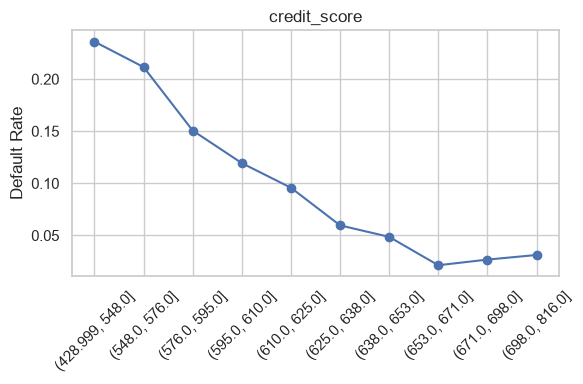

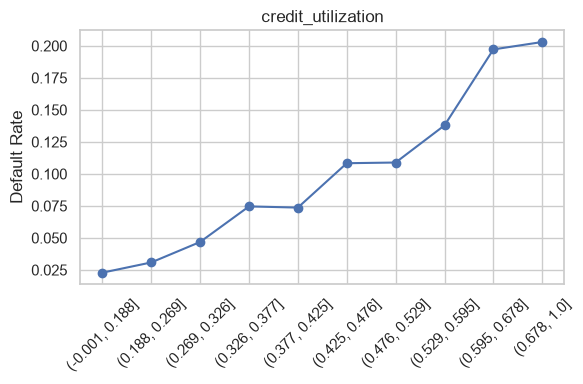

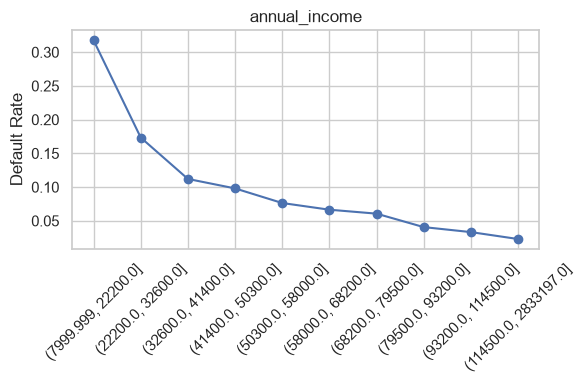

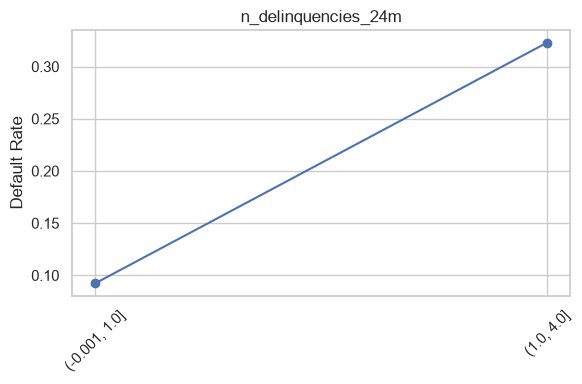

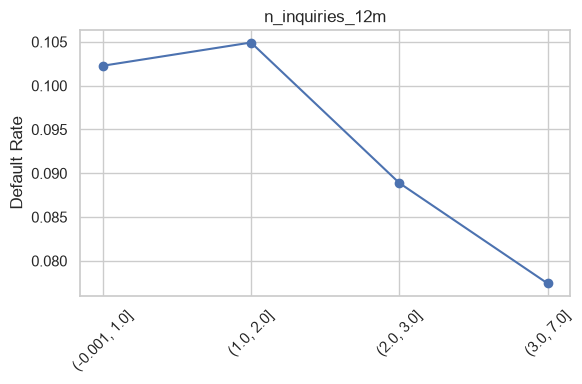

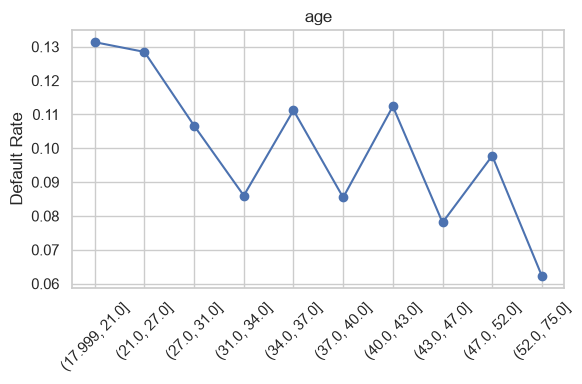

In [10]:
# --- ADD YOUR CODE BELOW ---
# For each column, explore whether its value predicts whether a customer will default.
# Useful approaches:
#   - Split customers into 10 equal groups by the column value; plot the default rate in each group
#   - Plot the distribution of defaulters vs non-defaulters on the same chart (overlapping histograms)
#   - For category columns, show a bar chart of default rate per category
# Which columns show the clearest separation between defaulters and non-defaulters?

#Numerical features to explore for default prediction
def plot_default_rate_numeric(df, feature, target="default_flag", bins=10):

    temp = df[[feature, target]].dropna().copy()

    temp["bin"] = pd.qcut(
        temp[feature],
        q=bins,
        duplicates="drop"
    )

    summary = (
        temp
        .groupby("bin")[target]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(6,4))

    plt.plot(
        range(len(summary)),
        summary[target],
        marker="o"
    )

    plt.xticks(
        range(len(summary)),
        summary["bin"].astype(str),
        rotation=45
    )

    plt.ylabel("Default Rate")
    plt.title(feature)

    plt.tight_layout()
    plt.show()

loan_data = loans.merge(
    customers,
    on="customer_id"
).merge(
    credit_history,
    on="customer_id"
)

numeric_features = [
    "credit_score",
    "credit_utilization",
    "annual_income",
    "n_delinquencies_24m",
    "n_inquiries_12m",
    "age"
]

for col in numeric_features:
    plot_default_rate_numeric(
        loan_data,
        col
    )

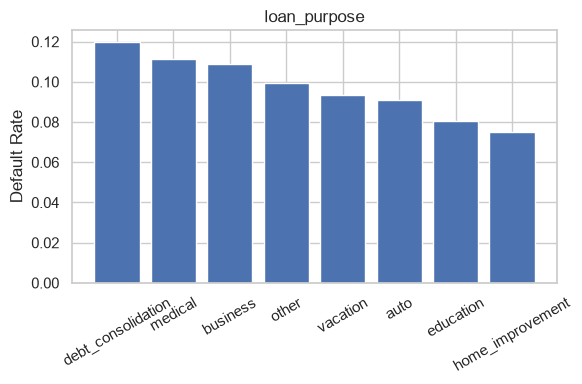

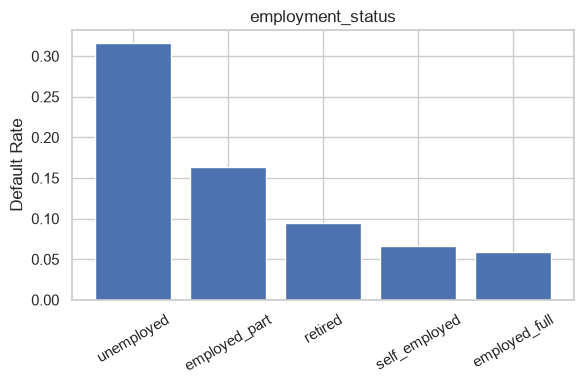

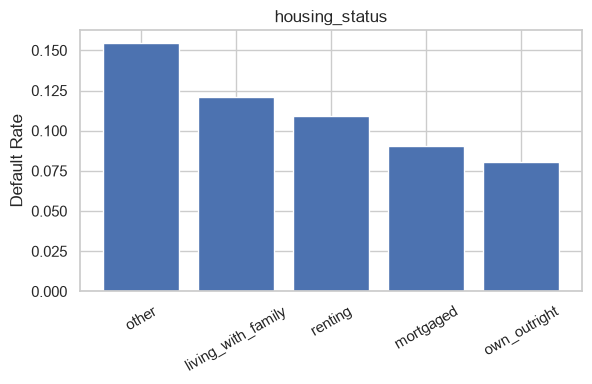

In [11]:
# Categorical features to explore for default prediction
def plot_default_rate_category(df, feature, target="default_flag"):

    summary = (
        df
        .groupby(feature)[target]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(6,4))

    plt.bar(
        summary.index.astype(str),
        summary.values
    )

    plt.ylabel("Default Rate")
    plt.title(feature)

    plt.xticks(rotation=30)

    plt.tight_layout()

    plt.show()

categorical_features = [
    "loan_purpose",
    "employment_status",
    "housing_status"
]

for col in categorical_features:

    plot_default_rate_category(
        loan_data,
        col
    )

**What did you find?** Name the three columns most strongly related to default and briefly explain why the relationship makes sense.

*Your answer:*

Overall: 

Among the numerical variables, credit_score, credit_utilization, and annual_income show the strongest relationships with loan default. The default rate decreases steadily as credit score and annual income increase, while it increases consistently with higher credit utilization. These monotonic trends indicate that the variables provide strong discrimination between low-risk and high-risk borrowers. Although n_delinquencies_24m also shows a noticeable increase in default rate, it contains only a small number of distinct values and therefore provides less detailed separation. In contrast, age and n_inquiries_12m display weaker and less consistent patterns, suggesting that they are less predictive when considered individually.

Among the categorical variables, employment_status shows the strongest relationship with loan default. Unemployed applicants have a substantially higher default rate than other employment groups, while full-time employed and self-employed applicants have the lowest default rates. This suggests that employment stability is an important indicator of repayment ability.

housing_status also demonstrates a meaningful relationship with default risk. Applicants who own their homes outright have the lowest default rate, whereas those in the "Other" housing category exhibit the highest default rate. This indicates that housing status may reflect financial stability and should be retained as a predictive feature.

loan_purpose shows a weaker but still noticeable relationship with default. Loans for debt consolidation have the highest default rate, whereas home improvement loans have the lowest. Although the separation is less pronounced than for employment or housing status, the variable still captures useful behavioural differences and may improve model performance when combined with other features.

Conclusion: 

Based on the exploratory analysis, the three variables most strongly related to loan default are credit_score, credit_utilization, and employment_status. credit_score shows the clearest inverse relationship with default, with the default rate decreasing consistently as credit scores increase. credit_utilization exhibits the opposite trend, where borrowers using a larger proportion of their available credit have progressively higher default rates. Among the categorical variables, employment_status provides the strongest separation, with unemployed applicants having a substantially higher default rate than applicants in stable employment. These three variables display clear and consistent patterns that align with established credit risk theory, making them strong candidates for predictive modelling.

Other variables, such as annual_income, housing_status, loan_purpose, and n_delinquencies_24m, also show meaningful relationships with default. However, their separation is either less consistent or less informative. For example, annual_income follows a decreasing trend but is influenced by extreme outliers, while housing_status and loan_purpose show smaller differences in default rates across categories. Although n_delinquencies_24m exhibits a noticeable increase in default risk, it contains only a few discrete values, limiting its ability to distinguish borrowers as effectively as the selected features. Therefore, these variables may still contribute to the final model but appear less predictive when examined individually during EDA.

### 3.4 Which Customer Groups are Riskiest? *(3 marks)*

The business wants to know which types of customer cause the most losses — not just who defaults most often, but also which groups represent a large share of the loan book.

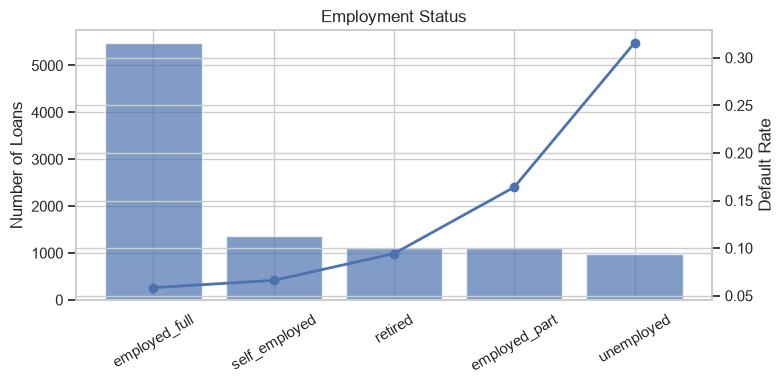

,Loan_Count,Default_Rate
employment_status,,
employed_full,5473,0.058
self_employed,1362,0.066
retired,1114,0.094
employed_part,1103,0.164
unemployed,988,0.316


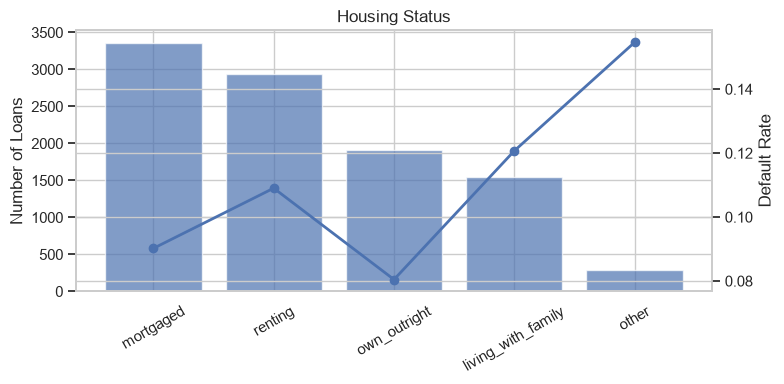

,Loan_Count,Default_Rate
housing_status,,
mortgaged,3359,0.090
renting,2935,0.109
own_outright,1914,0.080
living_with_family,1541,0.121
other,291,0.155


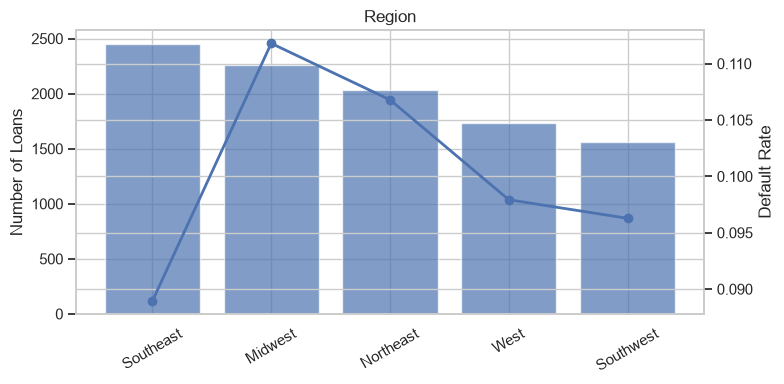

,Loan_Count,Default_Rate
region,,
Southeast,2451,0.089
Midwest,2263,0.112
Northeast,2032,0.107
West,1736,0.098
Southwest,1558,0.096


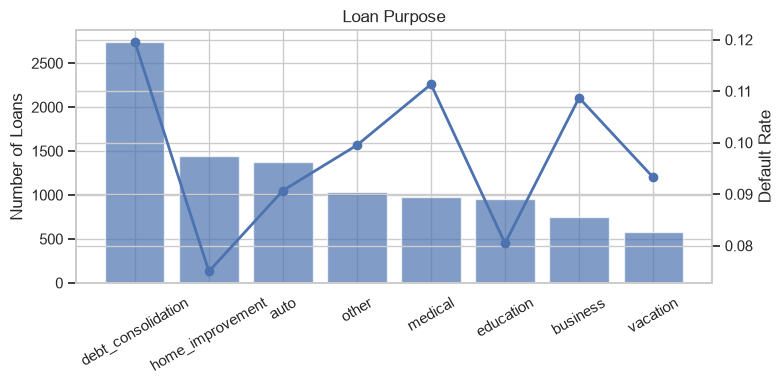

,Loan_Count,Default_Rate
loan_purpose,,
debt_consolidation,2735,0.120
home_improvement,1440,0.075
auto,1378,0.091
other,1035,0.100
medical,979,0.111
education,957,0.080
business,745,0.109
vacation,579,0.093


In [12]:
# --- ADD YOUR CODE BELOW ---
# For each category (employment status, housing type, region, loan purpose, etc.),
# show BOTH the default rate AND the number of loans in that category.
# A segment that has a 30% default rate but only 10 loans is less important than
# a segment with a 15% default rate and 2,000 loans.
#
# Also try:
# - A heatmap showing default rate for combinations of two categories
#   (e.g. employment type × housing type)
# - A chart showing how default rates changed over time (group loans by quarter of application date)


#Segment summary
def plot_segment_risk(df, feature, target="default_flag"):

    summary = (
        df.groupby(feature)
          .agg(
              Loan_Count=(target, "count"),
              Default_Rate=(target, "mean")
          )
          .sort_values("Loan_Count", ascending=False)
    )

    fig, ax1 = plt.subplots(figsize=(8,4))

    # Loan count (bars)
    ax1.bar(summary.index.astype(str),
            summary["Loan_Count"],
            alpha=0.7)

    ax1.set_ylabel("Number of Loans")
    ax1.set_xlabel("")
    ax1.tick_params(axis="x", rotation=30)

    # Default rate (line)
    ax2 = ax1.twinx()

    ax2.plot(summary.index.astype(str),
             summary["Default_Rate"],
             marker="o",
             linewidth=2)

    ax2.set_ylabel("Default Rate")

    plt.title(feature.replace("_"," ").title())
    plt.tight_layout()

    plt.show()

    display(summary.round(3))

#Plot segment risk for categorical features
segment_features = [
    "employment_status",
    "housing_status",
    "region",
    "loan_purpose"
]

for feature in segment_features:
    plot_segment_risk(loan_data, feature)


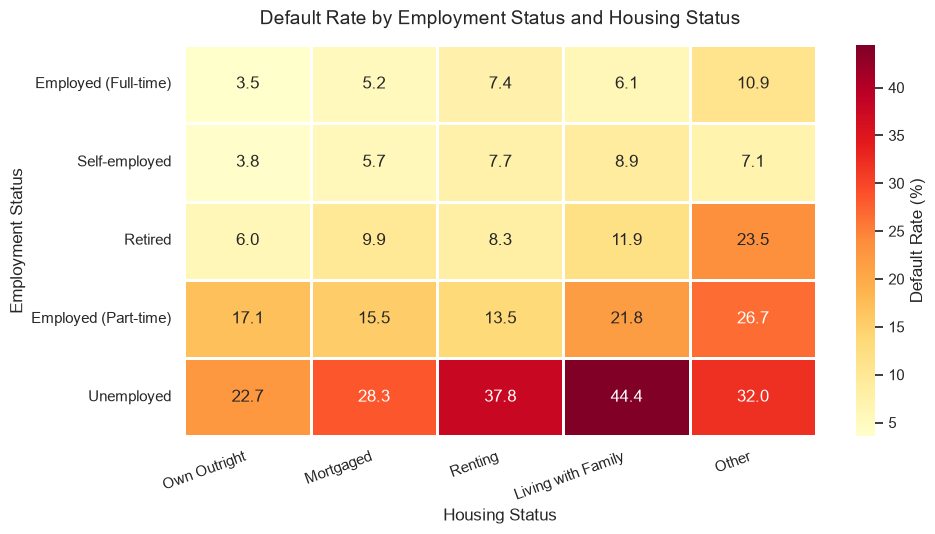

In [13]:
# Heatmap for combinations of two categorical features
# Default rate by Employment Status × Housing Status

# Create pivot table
heatmap_data = (
    loan_data
    .pivot_table(
        index="employment_status",
        columns="housing_status",
        values="default_flag",
        aggfunc="mean"
    )
)

# Reorder rows and columns for better interpretation
employment_order = [
    "employed_full",
    "self_employed",
    "retired",
    "employed_part",
    "unemployed"
]

housing_order = [
    "own_outright",
    "mortgaged",
    "renting",
    "living_with_family",
    "other"
]

heatmap_data = heatmap_data.reindex(
    index=employment_order,
    columns=housing_order
)

# Rename labels for presentation
heatmap_data.index = [
    "Employed (Full-time)",
    "Self-employed",
    "Retired",
    "Employed (Part-time)",
    "Unemployed"
]

heatmap_data.columns = [
    "Own Outright",
    "Mortgaged",
    "Renting",
    "Living with Family",
    "Other"
]

# Plot
plt.figure(figsize=(10, 5.5))

sns.heatmap(
    heatmap_data * 100,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Default Rate (%)"}
)

plt.title(
    "Default Rate by Employment Status and Housing Status",
    fontsize=14,
    pad=15
)

plt.xlabel("Housing Status")
plt.ylabel("Employment Status")

plt.xticks(rotation=20, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

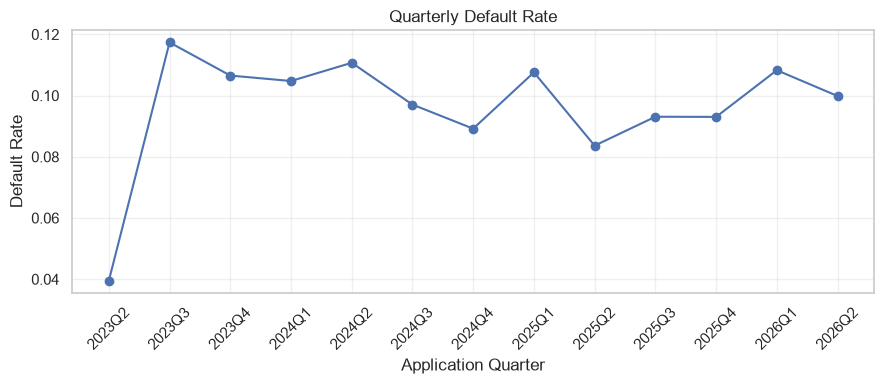

In [14]:
# Default rates over time (by quarter of application date)

# Default rate by application quarter

loan_data["application_date"] = pd.to_datetime(loan_data["application_date"])

quarterly_default = (
    loan_data
    .groupby(
        loan_data["application_date"].dt.to_period("Q")
    )["default_flag"]
    .mean()
)

plt.figure(figsize=(9,4))

plt.plot(
    quarterly_default.index.astype(str),
    quarterly_default.values,
    marker="o"
)

plt.title("Quarterly Default Rate")
plt.xlabel("Application Quarter")
plt.ylabel("Default Rate")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**What are the riskiest segments?** Name the two customer groups with the highest combination of default rate and loan volume, and explain why they matter most to the business.

*Your answer:*

Based on the exploratory analysis, the two riskiest customer groups are unemployed customers and customers who are renting their homes.

Unemployed customers exhibit the highest default rate (31.6%), which is substantially higher than all other employment groups. The heatmap further confirms that unemployed applicants consistently have elevated default rates across every housing category, indicating that unemployment is a strong indicator of financial vulnerability and repayment risk.

Customers who are renting represent one of the largest customer groups (2,935 loans) while also having a relatively high default rate (10.9%). Although the "Other" housing category has an even higher default rate (15.5%), it contains only 291 loans and therefore has a much smaller impact on the overall loan portfolio. From a business perspective, renting customers contribute more to the bank's overall credit risk because they combine a large loan volume with above-average default rates.

These findings highlight the importance of considering both default rate and loan volume when identifying high-risk customer segments. Focusing on large customer groups with elevated default rates is likely to have a greater impact on reducing the bank's overall credit losses than targeting only small, high-risk segments.

---
# SECTION 4 — Cleaning & Joining the Data *(12 marks)*

Fix the problems you found in Section 3, then combine all four tables into one dataset that is ready for modelling. Explain every decision you make.

In [15]:
# --- ADD YOUR CODE BELOW ---
# Steps to complete:

# Create cleaned copies of the original datasets
customers_clean = customers.copy()
credit_history_clean = credit_history.copy()
transactions_clean = transactions.copy()
loans_clean = loans.copy()

# 1. Remove duplicate loan applications.
#    Hint: a duplicate is a row with the same customer_id, application_date, and loan_amount.

# Check duplicate loan applications
duplicate_loans = loans_clean.duplicated(
    subset=["customer_id", "application_date", "loan_amount"]
)

print(f"Duplicate loan applications: {duplicate_loans.sum()}")

# Remove duplicate loan applications
loans_clean = (
    loans_clean
    .drop_duplicates(
        subset=["customer_id", "application_date", "loan_amount"]
    )
    .reset_index(drop=True)
)

# Verify no duplicate loan applications remain
duplicates_remaining = loans_clean.duplicated(
    subset=["customer_id", "application_date", "loan_amount"]
).sum()

print(f"Remaining duplicates: {duplicates_remaining}")
print(f"Final number of loan applications: {len(loans_clean)}")

# 2. Handle outliers in income.
#    A small number of customers have unrealistically high incomes. Cap or remove them.

# Calculate the 99th percentile of annual income
income_cap = customers_clean["annual_income"].quantile(0.99)

# Count customers above the threshold
n_capped = (customers_clean["annual_income"] > income_cap).sum()

print(f"99th percentile: £{income_cap:,.2f}")
print(f"Customers above the threshold: {n_capped}")

# Cap annual income at the 99th percentile
customers_clean["annual_income"] = customers_clean["annual_income"].clip(
    upper=income_cap
)

# Verify the results after capping
print(customers_clean["annual_income"].describe())

print(f"\nMaximum income after capping: £{customers_clean['annual_income'].max():,.2f}")

# 3. Summarise the transactions table to one row per customer.
#    Think about what summaries might signal financial stress:
#    e.g. total spend, number of transactions, how recently they transacted,
#    how many were cash advances, whether spending is increasing.

# Prepare transactions summary
# Ensure transaction date is in datetime format
transactions_clean["txn_date"] = pd.to_datetime(
    transactions_clean["txn_date"]
)

# Snapshot date from the data dictionary
snapshot_date = pd.Timestamp("2026-06-20")

#Aggregate transactions to one row per customer
transaction_summary = (
    transactions_clean
    .groupby("customer_id")
    .agg(
        total_spend=("txn_amount", "sum"),
        avg_transaction=("txn_amount", "mean"),
        max_transaction=("txn_amount", "max"),
        transaction_count=("txn_id", "count"),
        cash_stress_events=("cash_stress_flag", "sum"),
        last_transaction=("txn_date", "max")
    )
    .reset_index()
)

# Create derived features
# Days since last transaction
transaction_summary["days_since_last_transaction"] = (
    snapshot_date - transaction_summary["last_transaction"]
).dt.days

# Percentage of cash stress transactions
transaction_summary["cash_stress_rate"] = (
    transaction_summary["cash_stress_events"]
    / transaction_summary["transaction_count"]
)

#Remove temporary columns
transaction_summary = transaction_summary.drop(
    columns="last_transaction"
)

#Verify the transaction summary
print(transaction_summary.shape)

transaction_summary.head()

# 4. Fill in missing values.
#    For each column with missing values, choose a strategy and explain why.
#    (See the data dictionary for hints on what each column's missingness means.)

#Check missing values
# Check missing values before imputation
missing_summary = pd.DataFrame({
    "Missing Values": (
        customers_clean.isna().sum()
        .add(credit_history_clean.isna().sum(), fill_value=0)
        .add(loans_clean.isna().sum(), fill_value=0)
    )
})

display(missing_summary[missing_summary["Missing Values"] > 0])

# Handle missing values

#Annual_income
# Fill annual income using the median within each employment status
customers_clean["annual_income"] = (
    customers_clean
    .groupby("employment_status")["annual_income"]
    .transform(lambda x: x.fillna(x.median()))
)

#months_at_address
# Fill missing address tenure with the median
customers_clean["months_at_address"] = (
    customers_clean["months_at_address"]
    .fillna(customers_clean["months_at_address"].median())
)

#Credit score
# Create a missing indicator for credit score
credit_history_clean["credit_score_missing"] = (
    credit_history_clean["credit_score"]
    .isna()
    .astype(int)
)

# Fill missing credit scores with the median
credit_history_clean["credit_score"] = (
    credit_history_clean["credit_score"]
    .fillna(credit_history_clean["credit_score"].median())
)

#n_inquiries_12m
# Fill missing inquiries with the median
credit_history_clean["n_inquiries_12m"] = (
    credit_history_clean["n_inquiries_12m"]
    .fillna(credit_history_clean["n_inquiries_12m"].median())
)

#months_since_deliq
# Create an indicator for customers with previous delinquency
credit_history_clean["ever_delinquent"] = (
    credit_history_clean["months_since_deliq"]
    .notna()
    .astype(int)
)

# Fill customers with no delinquency history using a sentinel value
credit_history_clean["months_since_deliq"] = (
    credit_history_clean["months_since_deliq"]
    .fillna(999)
)

# loan_purpose
# Treat missing loan purpose as a separate category
loans_clean["loan_purpose"] = (
    loans_clean["loan_purpose"]
    .fillna("unknown")
)

#Verify missing values after imputation
# Verify that all missing values have been handled
print("Customers")
display(customers_clean.isna().sum()[customers_clean.isna().sum() > 0])

print("Credit History")
display(credit_history_clean.isna().sum()[credit_history_clean.isna().sum() > 0])

print("Loans")
display(loans_clean.isna().sum()[loans_clean.isna().sum() > 0])


# 5. Join all four tables together on customer_id.
#    The final dataset should have one row per loan application.
#
# Name your final dataset: master


master = None  # replace with your joined DataFrame

#Join all datasets on customer_id
# Join all cleaned tables into the final modelling dataset
master = (
    loans_clean
    .merge(customers_clean, on="customer_id", how="left")
    .merge(credit_history_clean, on="customer_id", how="left")
    .merge(transaction_summary, on="customer_id", how="left")
)

#Verify the final dataset
# Display the shape of the final dataset
print(f"Master dataset shape: {master.shape}")

# Check for missing customer IDs
print(f"Missing customer IDs: {master['customer_id'].isna().sum()}")

# Check duplicate loan applications
duplicates = master.duplicated(
    subset=["customer_id", "application_date", "loan_amount"]
).sum()

print(f"Duplicate loan applications: {duplicates}")

#Preview the final modeling dataset
master.head()

# ============================================================
# Final Validation
# ============================================================

print(f"Master dataset shape: {master.shape}")
print(f"Unique customers: {master['customer_id'].nunique()}")
print(f"Unique loan applications: {master['loan_id'].nunique()}")
print(f"Remaining missing values: {master.isna().sum().sum()}")

duplicates = master.duplicated(
    subset=["customer_id", "application_date", "loan_amount"]
).sum()

print(f"Duplicate loan applications: {duplicates}")

Duplicate loan applications: 41
Remaining duplicates: 0
Final number of loan applications: 9999
99th percentile: £192,570.00
Customers above the threshold: 77
count      7666.000000
mean      65390.384816
std       37557.882298
min        8000.000000
25%       37200.000000
50%       58500.000000
75%       86400.000000
max      192570.000000
Name: annual_income, dtype: float64

Maximum income after capping: £192,570.00
(8000, 8)


,Missing Values
annual_income,334.0
credit_score,252.0
loan_purpose,190.0
months_at_address,422.0
months_since_deliq,6222.0
n_inquiries_12m,390.0


Customers


Series([], dtype: int64)

Credit History


Series([], dtype: int64)

Loans


Series([], dtype: int64)

Master dataset shape: (9999, 39)
Missing customer IDs: 0
Duplicate loan applications: 0
Master dataset shape: (9999, 39)
Unique customers: 5699
Unique loan applications: 9999
Remaining missing values: 0
Duplicate loan applications: 0


**Explain your decisions.** For each missing-value column, state what you filled it with and why. Describe the transaction features you computed and what financial behaviour each one captures. State the final shape of `master`.

*Your answer:*
### Strategy for each missing values: 
1) annual_income contains missing values because some applicants chose not to disclose their income. Since the missingness is reported as Missing at Random (MAR), these values will be imputed using the median income within each employment_status group, which better preserves differences in earning levels across employment types.

2) months_at_address is missing due to a temporary application system issue rather than customer characteristics. As the missingness is unrelated to credit risk, these values will be imputed using the median address tenure, and a missing indicator may also be created to preserve information about the affected records.

3) credit_score is missing for customers with thin credit files, meaning they have little or no previous credit history. This missingness is informative because thin-file customers generally have higher credit risk. Therefore, a missing indicator will be created, and the missing values will be imputed separately to retain this business information.

4) n_inquiries_12m is missing because of a bureau system migration. As this is also considered Missing at Random (MAR), the values will be imputed using the median number of enquiries, while considering a missing indicator if it improves model performance.

5) months_since_deliq is a special case. A missing value does not indicate missing data; instead, it means the customer has never been delinquent. Therefore, these values will not be treated as ordinary missing values. Instead, an ever_delinquent indicator will be created, and missing values will be replaced with a sentinel value (e.g., 999) to represent "no delinquency history."

6) loan_purpose is missing because applicants were allowed to skip this optional field. Since the missingness itself has business meaning, missing values will be treated as a separate category, unknown, rather than being imputed with the most frequent loan purpose.

### Transactions feature
The transactions table was aggregated from multiple records into a single row per customer to enable joining with the other datasets. Several behavioural features were created to capture different aspects of customers' spending patterns. total_spend measures the overall amount spent, while transaction_count reflects the customer's level of transaction activity. avg_transaction and max_transaction describe typical and peak spending behaviour, which may indicate purchasing capacity or unusually large transactions. cash_stress_events counts the number of transactions flagged as cash advances, and cash_stress_rate measures the proportion of these transactions, both of which may signal financial stress or liquidity problems. days_since_last_transaction captures customer recency, where longer periods of inactivity may indicate lower engagement or changes in financial behaviour.

The final cleaned dataset, named master, was created by joining the cleaned customer, credit history, transaction summary, and loan tables using customer_id, with the loans table as the base table. The resulting dataset contains 9,999 loan applications, with one row per loan application, and is ready for predictive modelling.

---
# SECTION 5 — Creating New Features *(15 marks)*

Raw columns are often not the best inputs for a model. In this section you will create new features that encode domain knowledge about credit risk.

---

## Weight-of-Evidence (WoE) Encoding *(9 marks)*

For categorical columns (like employment type or loan purpose), a common technique in credit scoring is **Weight-of-Evidence (WoE) encoding**. The idea is to replace each category with a single number that reflects how risky that category is relative to the average.

**You must apply WoE encoding to at least three categorical columns.**

For each encoded column, also compute its **Information Value (IV)** — a number that tells you how useful the column is for predicting default:

| IV value | What it means |
|---|---|
| Below 0.02 | Not useful — consider leaving it out |
| 0.02 – 0.10 | Weakly predictive |
| 0.10 – 0.30 | Moderately predictive |
| Above 0.30 | Strongly predictive |

The formulas are:

$$\text{WoE for a category} = \ln\!\left(\frac{\text{fraction of defaulters in this category}}{\text{fraction of non-defaulters in this category}}\right)$$

$$\text{IV for a column} = \sum_{\text{categories}} \bigl(\text{fraction of defaulters} - \text{fraction of non-defaulters}\bigr) \times \text{WoE}$$

In [16]:
# --- ADD YOUR CODE BELOW ---
# 1. Write a function that computes WoE and IV for a categorical column.

def calculate_woe_iv(df, feature, target):
    """
    Calculate Weight of Evidence (WoE) and Information Value (IV)
    for a categorical feature.
    """

    woe_table = (
        df.groupby(feature)[target]
        .agg(
            Total="count",
            Defaulters="sum"
        )
        .reset_index()
    )

    # Calculate non-defaulters
    woe_table["Non_Defaulters"] = (
        woe_table["Total"] - woe_table["Defaulters"]
    )

    # Fractions
    total_defaulters = woe_table["Defaulters"].sum()
    total_non_defaulters = woe_table["Non_Defaulters"].sum()

    woe_table["Defaulter_Fraction"] = (
        woe_table["Defaulters"] / total_defaulters
    )

    woe_table["Non_Defaulter_Fraction"] = (
        woe_table["Non_Defaulters"] / total_non_defaulters
    )

    # Avoid division by zero
    woe_table["Defaulter_Fraction"] = (
        woe_table["Defaulter_Fraction"].replace(0, 0.0001)
    )

    woe_table["Non_Defaulter_Fraction"] = (
        woe_table["Non_Defaulter_Fraction"].replace(0, 0.0001)
    )

    # WoE (follow assignment formula)
    woe_table["WoE"] = np.log(
        woe_table["Defaulter_Fraction"]
        /
        woe_table["Non_Defaulter_Fraction"]
    )

    # IV
    woe_table["IV"] = (
        woe_table["Defaulter_Fraction"]
        -
        woe_table["Non_Defaulter_Fraction"]
    ) * woe_table["WoE"]

    iv = woe_table["IV"].sum()

    return woe_table, iv

# 2. Apply it to at least three categorical columns and print a summary table of IVs.

categorical_features = [
    "employment_status",
    "housing_status",
    "loan_purpose"
]

iv_summary = []

for feature in categorical_features:

    woe_table, iv = calculate_woe_iv(
        master,
        feature,
        "default_flag"
    )

    print(f"\nWoE Table: {feature}")
    display(woe_table)

    iv_summary.append({
        "Feature": feature,
        "IV": iv
    })

iv_summary = pd.DataFrame(iv_summary)

print("\nInformation Value Summary")
display(iv_summary.sort_values("IV", ascending=False))

# 3. Also try binning numeric columns (e.g. credit score into 10 equal groups)
#    and computing their IV — this tells you how predictive each numeric column is.

# Select numeric features
numeric_features = [
    "credit_score",
    "credit_utilization",
    "annual_income"
]

numeric_iv = []

for feature in numeric_features:

    # Create 10 equal-frequency bins
    temp = master.copy()

    temp[f"{feature}_bin"] = pd.qcut(
        temp[feature],
        q=10,
        duplicates="drop"
    )

    # Calculate WoE and IV
    _, iv = calculate_woe_iv(
        temp,
        f"{feature}_bin",
        "default_flag"
    )

    numeric_iv.append({
        "Feature": feature,
        "IV": iv
    })

# Display Information Value summary
numeric_iv = (
    pd.DataFrame(numeric_iv)
    .sort_values("IV", ascending=False)
)

print("Information Value Summary (Numeric Features)")
display(numeric_iv)

# 4. Create at least two new "ratio" features that combine existing columns.
#    Think about what combinations signal financial stress:
#    e.g. loan amount ÷ monthly income,  utilisation × number of delinquencies,
#         spend in last 3 months ÷ spend in previous 3 months (is spending accelerating?)

#Loan to Income Ratio
# Loan amount relative to monthly income
master["loan_to_income_ratio"] = (
    master["loan_amount"]
    /
    (master["annual_income"] / 12)
)

# Create utilisation × number of delinquencies feature
# Combined credit utilisation and delinquency behaviour
master["utilization_x_delinquency"] = (
    master["credit_utilization"]
    *
    master["n_delinquencies_24m"]
)
# Verify the new features

# Preview the new ratio features
master[
    [
        "loan_to_income_ratio",
        "utilization_x_delinquency"
    ]
].head()
master["n_delinquencies_24m"].value_counts().sort_index()



WoE Table: employment_status


,employment_status,Total,Defaulters,Non_Defaulters,Defaulter_Fraction,Non_Defaulter_Fraction,WoE,IV
0,employed_full,5449,318,5131,0.317049,0.570365,-0.587220,0.148752
1,employed_part,1099,181,918,0.180459,0.102045,0.570084,0.044702
2,retired,1111,104,1007,0.103689,0.111939,-0.076555,0.000632
3,self_employed,1358,89,1269,0.088734,0.141063,-0.463564,0.024258
4,unemployed,982,311,671,0.310070,0.074589,1.424808,0.335515



WoE Table: housing_status


,housing_status,Total,Defaulters,Non_Defaulters,Defaulter_Fraction,Non_Defaulter_Fraction,WoE,IV
0,living_with_family,1536,185,1351,0.184447,0.150178,0.205540,0.007044
1,mortgaged,3347,300,3047,0.299103,0.338706,-0.124346,0.004925
2,other,289,45,244,0.044865,0.027123,0.503279,0.008929
3,own_outright,1904,154,1750,0.153539,0.194531,-0.236634,0.009700
4,renting,2923,319,2604,0.318046,0.289462,0.094172,0.002692



WoE Table: loan_purpose


...


Information Value Summary


,Feature,IV
0,employment_status,0.553859
2,loan_purpose,0.035190
1,housing_status,0.033289


Information Value Summary (Numeric Features)


,Feature,IV
2,annual_income,0.716990
0,credit_score,0.699004
1,credit_utilization,0.492550


n_delinquencies_24m
0    7752
1    1892
2     317
3      32
4       6
Name: count, dtype: int64

*(6 marks)* **Explain your new features.** For each one, state in one sentence what it measures and what a high value signals about the borrower.

*Your answer:*

loan_to_income_ratio measures the size of the loan relative to the borrower's monthly income. A high value indicates that the borrower is taking on a larger debt burden relative to their income, which may increase the risk of default.

utilization_x_delinquency combines credit utilisation with the number of recent delinquencies. A high value indicates that the borrower both relies heavily on available credit and has a history of missed payments, suggesting a higher level of financial stress.

---
# SECTION 6 — Training Models *(20 marks)*

Train **at least two different types of model** and compare them. For each model, explain your choices.

**Important rules:**
- Use `random_state=42` everywhere randomness is involved.
- Hold out 20% of `loans.csv` as a local validation set — use `train_test_split` with `stratify=y`.
- Do your tuning on the training portion only; evaluate on the validation set.

In [17]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# --- ADD YOUR CODE BELOW ---
# 1. Define your feature columns and target:
#   # Define the target variable
y = master["default_flag"]
# Exclude identifier, date and target columns
exclude_columns = [
    "loan_id",
    "customer_id",
    "application_date",
    "date_of_birth",
    "default_flag",
    "loss_given_default"
]

feature_cols = [
    col for col in master.columns
    if col not in exclude_columns
]

X = master[feature_cols]
# Check remaining categorical features
X.select_dtypes(include="object").columns.tolist()

#    Exclude: loan_id, customer_id, dates, default_flag, loss_given_default,
#    and any raw category columns you already replaced with WoE numbers.
#
# 2. Split into train / validation:
#    X_train, X_val, y_train, y_val = train_test_split(
#        X, y, test_size=0.20, stratify=y, random_state=42)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

#Verify the split
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)

# 3. Optionally use 5-fold cross-validation on X_train to tune hyperparameters.
#    Convert AUC to Gini with:  gini = 2 * auc - 1

# Create a stratified 5-fold cross-validation object
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Training set: (7999, 35)
Validation set: (2000, 35)


In [18]:
# --- MODEL 1 ---
# Name: Logistic Regression

# --- ADD YOUR CODE BELOW ---
## Encode categorical variables
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include="object").columns

# Create One-Hot Encoder
encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

# Fit on training data only
X_train_encoded = encoder.fit_transform(
    X_train[categorical_cols]
)

X_val_encoded = encoder.transform(
    X_val[categorical_cols]
)

##Combine encoded and numeric features

# Convert encoded arrays to DataFrames
encoded_train = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_train.index
)

encoded_val = pd.DataFrame(
    X_val_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_val.index
)

# Keep numeric columns
X_train_num = X_train.drop(columns=categorical_cols)
X_val_num = X_val.drop(columns=categorical_cols)

# Final datasets
X_train_final = pd.concat(
    [X_train_num, encoded_train],
    axis=1
)

X_val_final = pd.concat(
    [X_val_num, encoded_val],
    axis=1
)

## Create Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

## Cross-validation
# Evaluate using 5-fold cross-validation
lr_cv_auc = cross_val_score(
    lr_model,
    X_train_final,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

lr_cv_gini = 2 * lr_cv_auc - 1

print(f"Mean CV AUC : {lr_cv_auc.mean():.4f}")
print(f"Mean CV Gini: {lr_cv_gini.mean():.4f}")

## Train model
# Train Logistic Regression
lr_model.fit(
    X_train_final,
    y_train
)

## Evaluate on validation set

# Predict probabilities
lr_prob = lr_model.predict_proba(
    X_val_final
)[:, 1]

# Validation AUC
lr_auc = roc_auc_score(
    y_val,
    lr_prob
)

# Validation Gini
lr_gini = 2 * lr_auc - 1

print(f"Validation AUC : {lr_auc:.4f}")
print(f"Validation Gini: {lr_gini:.4f}")


Mean CV AUC : 0.7732
Mean CV Gini: 0.5464
Validation AUC : 0.7834
Validation Gini: 0.5668


*(6 marks)* **Model 1 — explain your choices.** Why this algorithm? How did you handle the class imbalance? What is its main limitation for this problem?

*Your answer:*

Logistic Regression was selected as the baseline model because it is simple, interpretable, and widely used in credit scoring. It estimates the Probability of Default (PD) directly and provides a strong benchmark for comparing the performance of more complex machine learning models.

The dataset is imbalanced, with approximately 10% defaulted loans and 90% non-defaulted loans. To address this, class_weight="balanced" was used in Logistic Regression, which automatically assigns a higher weight to the minority default class during training. Model performance was evaluated using ROC AUC and the corresponding Gini coefficient instead of accuracy, as these metrics are more appropriate for imbalanced classification problems.

The main limitation of Logistic Regression is that it assumes a linear relationship between the input features and the log-odds of default. As a result, it may not capture complex non-linear relationships or feature interactions, which may reduce its predictive performance compared with tree-based models such as Random Forest.


In [19]:
# --- MODEL 2 ---
# Name: Random Forest

# --- ADD YOUR CODE BELOW ---

# Create the model 
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

## Cross validation
# Evaluate using 5-fold cross-validation
rf_cv_auc = cross_val_score(
    rf_model,
    X_train_final,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

rf_cv_gini = 2 * rf_cv_auc - 1

print(f"Mean CV AUC : {rf_cv_auc.mean():.4f}")
print(f"Mean CV Gini: {rf_cv_gini.mean():.4f}")

## Train model
# Train Random Forest
rf_model.fit(
    X_train_final,
    y_train
)

## Evaluate on validation set
# Predict probabilities
rf_prob = rf_model.predict_proba(
    X_val_final
)[:, 1]

# Validation AUC
rf_auc = roc_auc_score(
    y_val,
    rf_prob
)

# Validation Gini
rf_gini = 2 * rf_auc - 1

print(f"Validation AUC : {rf_auc:.4f}")
print(f"Validation Gini: {rf_gini:.4f}")



Mean CV AUC : 0.8155
Mean CV Gini: 0.6310
Validation AUC : 0.8168
Validation Gini: 0.6335


*(6 marks)* **Model 2 — explain your choices.** How does this model learn differently from Model 1, and what did that difference mean for your results?

*Your answer:*

Random Forest was selected because it is an ensemble tree-based model that can automatically capture non-linear relationships and complex interactions between variables. Unlike Logistic Regression, it does not assume a linear relationship between the predictors and the probability of default, making it suitable for modelling more complex credit risk patterns.

Unlike Logistic Regression, which learns a single linear decision boundary, Random Forest builds many decision trees using different subsets of the training data and combines their predictions. This enables the model to capture non-linear relationships and interactions between variables that Logistic Regression may miss. As a result, Random Forest achieved higher predictive performance, improving the validation AUC from 0.7834 to 0.8168 and the validation Gini from 0.5668 to 0.6335, indicating better separation between default and non-default borrowers.

Class imbalance was handled by setting class_weight="balanced", which assigns greater importance to the minority default class during training. Model performance was evaluated using ROC AUC and the corresponding Gini coefficient rather than accuracy, as these metrics provide a more appropriate assessment for imbalanced credit risk datasets.

The main limitation of Random Forest is its lower interpretability compared with Logistic Regression. Although it generally provides better predictive performance, it is more difficult to explain how individual features contribute to each prediction, which can be a disadvantage in regulated credit scoring environments where model transparency is important.

In [20]:
# After all models are trained, store your best model's predicted probabilities here:
# Predict probabilities using the best-performing model
best_prob = rf_prob

# Store the fitted model object
best_model = rf_model

*(8 marks)* **Which model did you choose and why?** Give your Gini scores and state your recommendation clearly.

*Your answer:*

Two models were evaluated: Logistic Regression and Random Forest. Logistic Regression achieved a mean cross-validation Gini of 0.5464 and a validation Gini of 0.5668, providing a strong and interpretable baseline for credit scoring. Random Forest achieved a higher mean cross-validation Gini of 0.6310 and a validation Gini of 0.6335, demonstrating better predictive performance and stronger separation between default and non-default borrowers. Since Random Forest consistently outperformed Logistic Regression on both cross-validation and the hold-out validation set, it was selected as the final model for the remaining analysis. Although Logistic Regression is easier to interpret, Random Forest provides a better balance between predictive accuracy and generalisation for this dataset.

---
# SECTION 7 — Evaluating Your Model *(8 marks)*

A single number is not enough to trust a model. Use the diagnostics below to understand where your model works well and where it struggles.

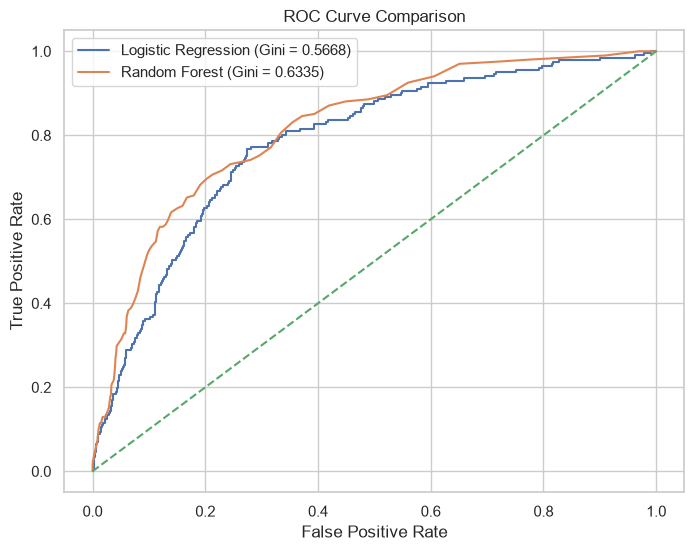

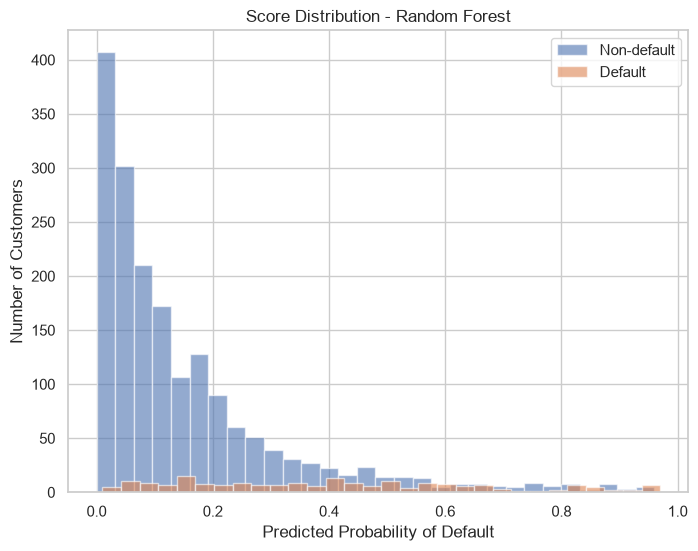

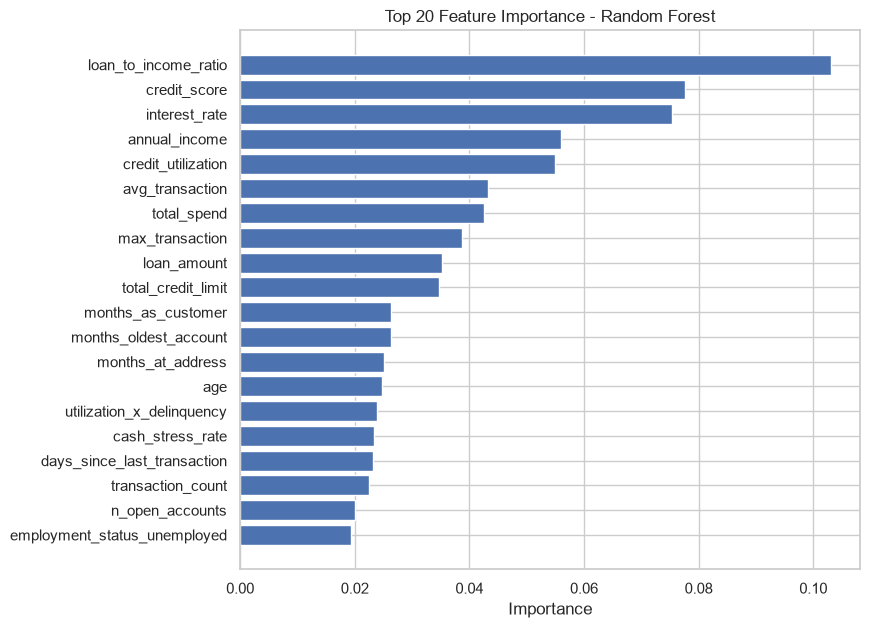

KS Statistic: 0.4942


<Figure size 700x600 with 0 Axes>

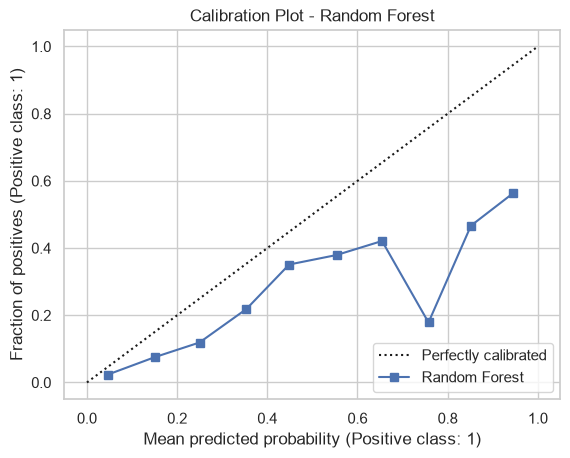

In [21]:
# --- ADD YOUR CODE BELOW ---
# Required plots:
#   1. ROC curve — one line per model on the same chart.
#      Label each line with the model name and its Gini score.
#      (ROC curve plots "true positive rate" vs "false positive rate" at every threshold.)

## Compare ROC curves
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Compute ROC curve for Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y_val, lr_prob)

# Compute ROC curve for Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_val, rf_prob)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (Gini = {lr_gini:.4f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (Gini = {rf_gini:.4f})"
)

# Random classifier
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

#   2. Score distribution — for your best model, plot two overlapping histograms:
#      one for customers who defaulted, one for those who didn't.
#      Good separation = the two humps barely overlap.

# Plot score distributions for the best model
plt.figure(figsize=(8, 6))

plt.hist(
    rf_prob[y_val == 0],
    bins=30,
    alpha=0.6,
    label="Non-default"
)

plt.hist(
    rf_prob[y_val == 1],
    bins=30,
    alpha=0.6,
    label="Default"
)

plt.xlabel("Predicted Probability of Default")
plt.ylabel("Number of Customers")
plt.title("Score Distribution - Random Forest")
plt.legend()

plt.show()

#   3. Feature importance — which columns did your best model rely on most?
#      Plot the top 20 most important features as a horizontal bar chart.

# Calculate feature importance 
# Extract feature importance
feature_importance = (
    pd.DataFrame({
        "Feature": X_train_final.columns,
        "Importance": rf_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .head(20)
)

#Plot feature importance
# Plot top 20 feature importance
plt.figure(figsize=(8, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 20 Feature Importance - Random Forest")

plt.show()


# Optional (recommended for Distinction):
#   4. KS statistic — the maximum gap between the defaulter and non-defaulter score CDFs.
from scipy.stats import ks_2samp

# Calculate KS statistic
ks_statistic, p_value = ks_2samp(
    rf_prob[y_val == 0],
    rf_prob[y_val == 1]
)

print(f"KS Statistic: {ks_statistic:.4f}")

#   5. Calibration plot — does "predicted 20% default" actually mean 1 in 5 defaults?
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

# Plot calibration curve for the best model
plt.figure(figsize=(7, 6))

CalibrationDisplay.from_predictions(
    y_val,
    rf_prob,
    n_bins=10,
    name="Random Forest"
)

plt.title("Calibration Plot - Random Forest")
plt.show()

**What do the plots tell you?** Do the defaulters and non-defaulters separate clearly in the score distribution? Do the top features make sense from a credit-risk perspective?

*Your answer:*

The score distribution shows partial separation between defaulters and non-defaulters rather than complete separation. Most non-default borrowers receive low predicted probabilities, while defaulted borrowers are more concentrated at higher predicted probabilities. However, there is still noticeable overlap between the two distributions, indicating that some high-risk non-defaulters and low-risk defaulters are difficult to distinguish. This level of separation is consistent with the model's validation Gini score of 0.6335 and KS statistic of 0.4942, suggesting that the Random Forest model provides good, although not perfect, discrimination.

The feature importance results are consistent with established credit risk principles. The most influential variables include loan-to-income ratio, credit score, interest rate, annual income, and credit utilisation, all of which are well-known indicators of a borrower's repayment capacity and creditworthiness. Transaction-based features such as average transaction amount, total spending, and cash stress rate also contribute to the model, indicating that recent spending behaviour provides additional information beyond traditional credit bureau variables. Overall, the most important features are economically meaningful and align well with expected drivers of default risk.

---
# SECTION 8 — Business Impact *(12 marks)*

Translate your model's predictions into a lending policy and work out how much money the bank could save.

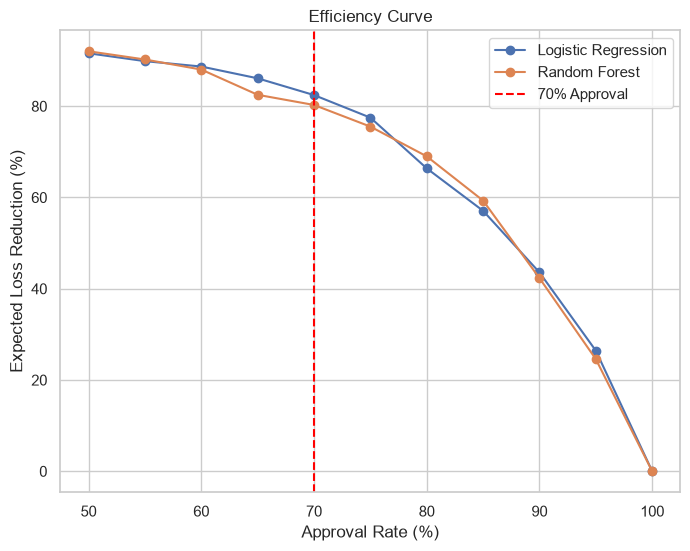

In [22]:
# *(7 marks)* --- ADD YOUR CODE BELOW ---
#
# The bank's lending policy:
#   Rank all applicants from lowest predicted default probability to highest.
#   Approve the lowest-risk X% of applicants. Reject the rest.
#
# Step 1: Write a function  expected_loss(y_true, y_prob, lgd, approval_rate)
#   that returns:
#   - el_approve_all  : total £ lost if the bank approved everyone
#   - el_model_policy : total £ lost if the bank uses the model at the given approval rate
#   - el_reduction    : the fraction saved  (1 - el_model_policy / el_approve_all)
#
# Step 2: Use the validation split you already made in Section 6:
#   val_lgd = master.loc[X_val.index, 'loss_given_default'].values
#
# Step 3: Compute EL reduction at 70% approval rate for all your models.
#
# Step 4: Plot the "efficiency curve":
#   x-axis = approval rate from 50% to 100%
#   y-axis = expected loss reduction (%)
#   Draw one line per model. Add a vertical line at 70% (the business constraint).

# Loss Given Default (LGD) for the validation set
val_lgd = master.loc[X_val.index, "loss_given_default"].values

# Create the expected loss function

def expected_loss(y_true, y_prob, lgd, approval_rate):
    """
    Calculate expected loss under a lending policy.

    Parameters
    ----------
    y_true : Actual default labels
    y_prob : Predicted default probabilities
    lgd : Loss Given Default (£)
    approval_rate : Percentage of applications to approve (0–1)

    Returns
    -------
    el_approve_all : Expected loss if everyone is approved
    el_model_policy : Expected loss using the model
    el_reduction : Percentage reduction in expected loss
    """

    # Create a DataFrame for ranking applicants
    results = pd.DataFrame({
        "default_flag": y_true,
        "predicted_prob": y_prob,
        "lgd": lgd
    })

    # Expected loss if everyone is approved
    el_approve_all = (
        results["default_flag"] * results["lgd"]
    ).sum()

    # Rank applicants from lowest to highest predicted risk
    results = results.sort_values(
        by="predicted_prob",
        ascending=True
    )

    # Approve only the lowest-risk applicants
    n_approve = int(len(results) * approval_rate)

    approved = results.iloc[:n_approve]

    # Expected loss under the lending policy
    el_model_policy = (
        approved["default_flag"] * approved["lgd"]
    ).sum()

    # Percentage reduction in expected loss
    el_reduction = 1 - (
        el_model_policy / el_approve_all
    )

    return (
        el_approve_all,
        el_model_policy,
        el_reduction
    )

# Compare models at 70% approval rate
approval_rate = 0.70

# Logistic Regression
lr_el_all, lr_el_model, lr_reduction = expected_loss(
    y_val,
    lr_prob,
    val_lgd,
    approval_rate
)

# Random Forest
rf_el_all, rf_el_model, rf_reduction = expected_loss(
    y_val,
    rf_prob,
    val_lgd,
    approval_rate
)

# Display results
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "EL (Approve All)": [lr_el_all, rf_el_all],
    "EL (Model Policy)": [lr_el_model, rf_el_model],
    "EL Reduction (%)": [
        lr_reduction * 100,
        rf_reduction * 100
    ]
})

results

# Efficiency curve
approval_rate = 0.70

# Logistic Regression
lr_el_all, lr_el_model, lr_reduction = expected_loss(
    y_val,
    lr_prob,
    val_lgd,
    approval_rate
)

# Random Forest
rf_el_all, rf_el_model, rf_reduction = expected_loss(
    y_val,
    rf_prob,
    val_lgd,
    approval_rate
)

# Display results
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "EL (Approve All)": [lr_el_all, rf_el_all],
    "EL (Model Policy)": [lr_el_model, rf_el_model],
    "EL Reduction (%)": [
        lr_reduction * 100,
        rf_reduction * 100
    ]
})

results

# Approval rates from 50% to 100%
approval_rates = np.arange(0.50, 1.01, 0.05)

lr_curve = []
rf_curve = []

for rate in approval_rates:

    _, _, lr_curve_reduction = expected_loss(
        y_val,
        lr_prob,
        val_lgd,
        rate
    )

    _, _, rf_curve_reduction = expected_loss(
        y_val,
        rf_prob,
        val_lgd,
        rate
    )

    lr_curve.append(lr_curve_reduction * 100)
    rf_curve.append(rf_curve_reduction * 100)

# Plot 
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(
    approval_rates * 100,
    lr_curve,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    approval_rates * 100,
    rf_curve,
    marker="o",
    label="Random Forest"
)

plt.axvline(
    x=70,
    linestyle="--",
    color="red",
    label="70% Approval"
)

plt.xlabel("Approval Rate (%)")
plt.ylabel("Expected Loss Reduction (%)")
plt.title("Efficiency Curve")

plt.legend()

plt.show()

In [23]:
import joblib

# --- ADD YOUR CODE BELOW ---
# Save your trained model so it can be loaded without retraining:
#
# joblib.dump(best_model, 'model.pkl')
# print('Model saved to model.pkl')
#
# Verify it loads and still predicts correctly:
# loaded = joblib.load('model.pkl')
# check_prob = loaded.predict_proba(X_val)[:, 1]
# print(f'Reload check — Gini: {2 * roc_auc_score(y_val, check_prob) - 1:.4f}')

from sklearn.metrics import roc_auc_score

# Save the best model
joblib.dump(best_model, "model.pkl")
print("Model saved to model.pkl")

# Load the saved model
loaded = joblib.load("model.pkl")

# Verify that the loaded model gives the same predictions
check_prob = loaded.predict_proba(X_val_final)[:, 1]

check_auc = roc_auc_score(y_val, check_prob)
check_gini = 2 * check_auc - 1

print(f"Reload check — AUC : {check_auc:.4f}")
print(f"Reload check — Gini: {check_gini:.4f}")


Model saved to model.pkl
Reload check — AUC : 0.8168
Reload check — Gini: 0.6335


In [24]:
print(f"EL approve all : {rf_el_all:,.2f}")
print(f"EL model policy: {rf_el_model:,.2f}")
print(f"Reduction      : {rf_reduction:.4f}")
print(f"Reduction (%)  : {rf_reduction*100:.2f}%")

EL approve all : 2,384,266.94
EL model policy: 470,513.79
Reduction      : 0.8027
Reduction (%)  : 80.27%


In [25]:
deployment_threshold = 25

if rf_reduction * 100 >= deployment_threshold:
    print("Recommendation: Deploy the Random Forest model.")
else:
    print("Recommendation: Do not deploy the model.")

Recommendation: Deploy the Random Forest model.


---
# SECTION 9 — Monitoring for Drift in Production *(5 marks)*

Once deployed, a model can degrade over time due to two types of drift:

- **Input drift**: the distribution of incoming applicants changes (e.g. a new marketing campaign attracts a different customer profile than the training data).
- **Target drift**: the relationship between inputs and default changes (e.g. the same credit score now predicts a higher default rate than it did at training time).

**9.1** *(2 marks)* Propose how you would detect **input drift** on the live application stream.

*Your answer:*

Input drift can be detected by continuously monitoring whether the distributions of incoming applicants differ from those observed during model training. Since the Random Forest model relies heavily on features such as loan-to-income ratio, credit score, annual income, credit utilisation, and average transaction amount, these variables should be monitored using summary statistics and distribution comparison methods such as the Population Stability Index (PSI) or histogram comparisons. If these feature distributions change significantly beyond predefined thresholds, it may indicate that the applicant population has shifted and the model should be reviewed or retrained before predictive performance deteriorates.

---

**9.2** *(3 marks)* Propose how you would detect **target drift** once enough live default outcomes are available.

*Your answer:*

Once enough live default outcomes become available, target drift can be detected by monitoring whether the model's predictive performance deteriorates over time. The validation model achieved a Gini coefficient of 0.6335, which can be used as the baseline performance. On each monitoring period (e.g., monthly or quarterly), key metrics including ROC AUC, Gini coefficient, KS statistic, and calibration should be recomputed using the newly observed default outcomes. In addition, observed default rates should be compared across predicted risk bands to verify whether customers with similar predicted probabilities continue to exhibit similar default behaviour. A sustained decline in these metrics or poor calibration would indicate target drift, suggesting that the model should be recalibrated or retrained using more recent data.



---
# EXTENSION *(10 marks)*

Attempt **both** of the following (5 marks each). Explain your findings clearly.

| Task | What to do | Marks |
|---|---|---|
| **Fairness check** | Do customers in different regions get approved at very different rates? Is this because they are genuinely riskier, or could the model be picking up a proxy for something else? What regulatory problem could this create? | 5 |
| **SHAP explanations** | Use the SHAP library to explain why your model gave a high or low risk score to three specific customers. Do the explanations make intuitive sense given their income, loan amount, and repayment history? | 5 |

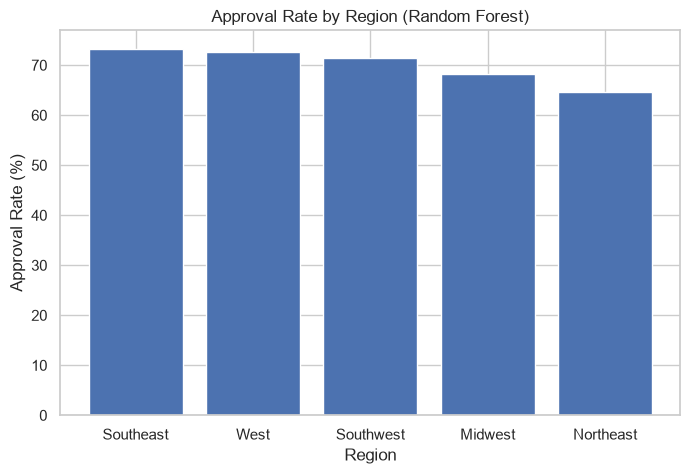

In [26]:
## Task 1 Fainerness Check

# Determine approved customers (70% approval policy)
# Create validation results
fairness_df = master.loc[X_val.index, ["region"]].copy()

fairness_df["predicted_prob"] = rf_prob

# Rank applicants by predicted probability
fairness_df = fairness_df.sort_values(
    by="predicted_prob",
    ascending=True
)

# Approve the lowest-risk 70%
n_approve = int(len(fairness_df) * 0.70)

fairness_df["approved"] = 0
fairness_df.iloc[:n_approve, fairness_df.columns.get_loc("approved")] = 1

# Approval rates by region
approval_by_region = (
    fairness_df
    .groupby("region")["approved"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="Approval Rate (%)")
)

approval_by_region

# Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    approval_by_region["region"],
    approval_by_region["Approval Rate (%)"]
)

plt.ylabel("Approval Rate (%)")
plt.xlabel("Region")
plt.title("Approval Rate by Region (Random Forest)")

plt.show()

## Comment for this task 

The approval rates across regions are relatively similar, ranging from approximately 64% to 73%. While applicants from the Southeast and West receive slightly higher approval rates than those from the Northeast, the differences are modest rather than extreme. Based on these results alone, there is no strong evidence that the model systematically disadvantages a particular region. The observed variation may reflect genuine differences in applicants' underlying credit risk rather than unfair treatment. However, because region can act as a proxy for socioeconomic characteristics, the bank should continue monitoring approval rates and model performance across regions to ensure compliance with fairness and anti-discrimination regulations.

,Risk Level,Predicted Probability
0,High Risk Customer,0.97
1,Medium Risk Customer,0.18
2,Low Risk Customer,0.00


High Risk Customer


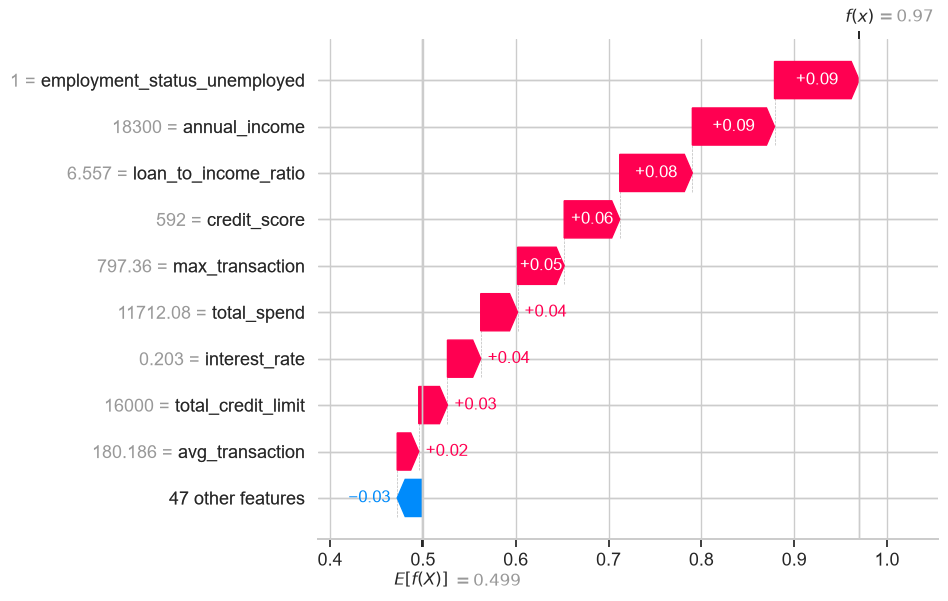

Medium Risk Customer


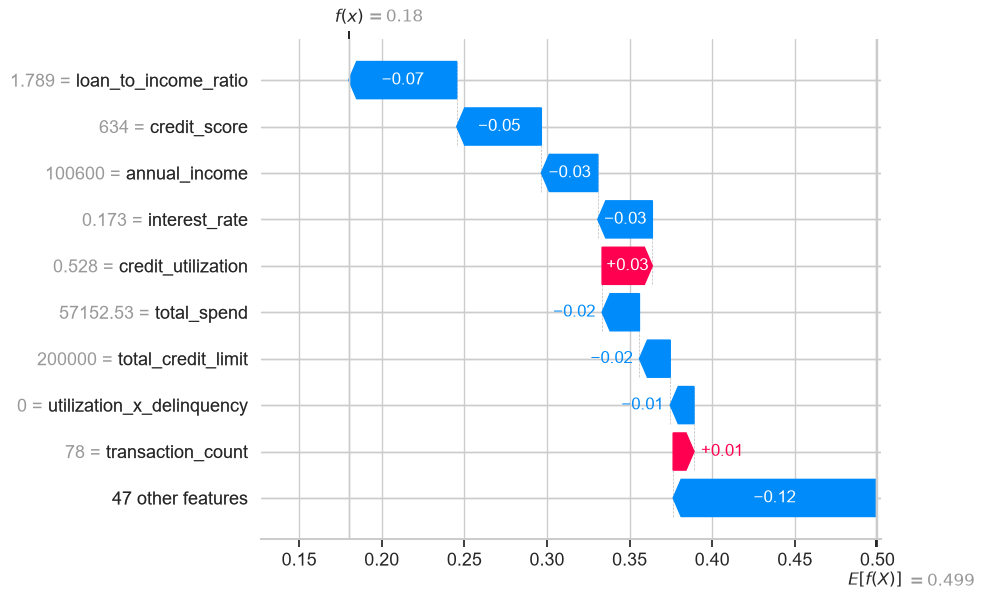

Low Risk Customer


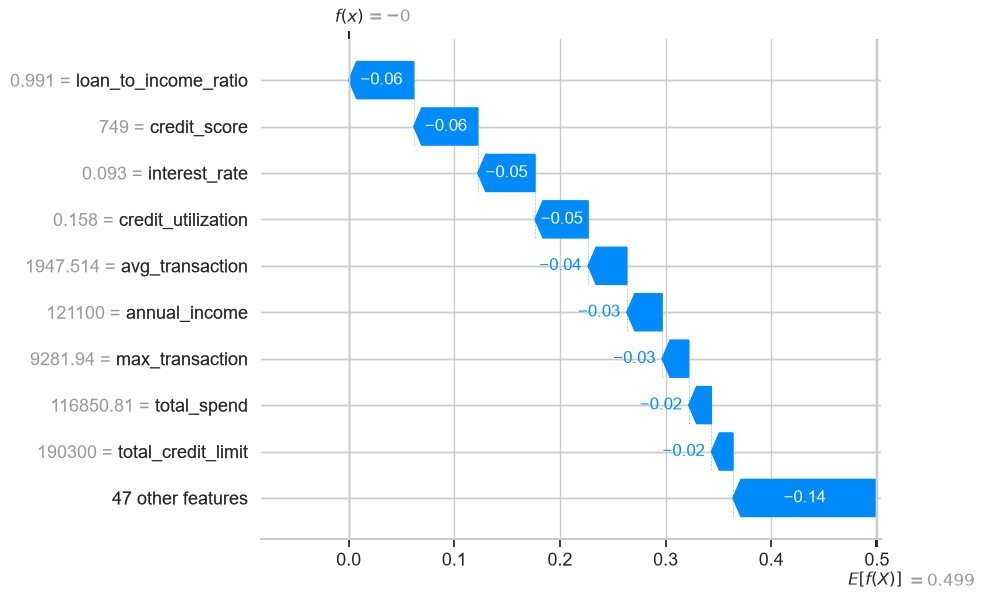

In [31]:
## Task 2 SHAP explanation
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Select three customers
high_idx = rf_prob.argmax()
low_idx = rf_prob.argmin()
medium_idx = abs(rf_prob - rf_prob.mean()).argmin()

selected = [high_idx, medium_idx, low_idx]
labels = ["High Risk Customer", "Medium Risk Customer", "Low Risk Customer"]

# Display customer information
comparison = pd.DataFrame({
    "Risk Level": labels,
    "Predicted Probability": rf_prob[selected]
})

display(comparison)

# SHAP waterfall plots
for idx, label in zip(selected, labels):

    print("=" * 70)
    print(label)

    # Explain one customer
    explanation = explainer(X_val_final.iloc[[idx]])

    # Plot SHAP values for the default class (class = 1)
    shap.plots.waterfall(
        explanation[0, :, 1],
        max_display=10,
        show=True
    )

## Comment for this task 

### High Risk Customer (Predicted default probability = 0.97)

The model assigned this customer a very high default probability (0.97). The largest positive contributors to risk were being unemployed, a very low annual income (£18,300), a high loan-to-income ratio (6.56), a relatively low credit score (592), and a high interest rate (20.3%). These factors all increase the predicted probability of default because they indicate limited repayment capacity and weaker creditworthiness. The explanation is intuitive, as the customer has both low income relative to the loan amount and characteristics commonly associated with higher credit risk.

### Medium Risk Customer (Predicted default probability = 0.18)

This customer received a moderate default probability (0.18). Several factors reduced the predicted risk, including a higher credit score (634), higher annual income (£100,600), and a much lower loan-to-income ratio (1.79). However, credit utilisation (52.8%) and a relatively higher transaction count slightly increased the predicted risk. Overall, the customer's stronger financial profile outweighs these risk factors, resulting in a moderate rather than high-risk prediction. This explanation is consistent with expected credit risk behaviour.

### Low Risk Customer (Predicted default probability ≈ 0.00)

The model predicted an almost zero probability of default for this customer. The strongest factors reducing risk were a high credit score (749), high annual income (£121,100), a low loan-to-income ratio (0.99), low credit utilisation (15.8%), and a relatively low interest rate (9.3%). These characteristics indicate strong repayment capacity and responsible credit usage, making the prediction of very low default risk reasonable. The explanation aligns well with established credit scoring principles.

### Conclusion 

Overall, the SHAP explanations are intuitive and consistent with established credit risk principles. Customers with low income, high loan-to-income ratios, lower credit scores, and weaker employment status receive higher predicted default probabilities, while customers with higher income, stronger credit scores, lower leverage, and lower credit utilisation receive lower predicted risk scores. The explanations therefore support the interpretability of the Random Forest model and demonstrate that its predictions are based on financially meaningful factors rather than arbitrary patterns.
